#### Importing packages

In [127]:
import pandas as pd
import requests 
import json
import os
#import networkx as nx

import matplotlib.pyplot as plt
#from wordcloud import WordCloud
from matplotlib import cm
from matplotlib.patches import Patch

from collections import defaultdict
import spacy
#import Functions as fn
#import seaborn as sns
import numpy as np  
#from fitter import Fitter
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re
from wordcloud import WordCloud

#### Importing datasets

In [2]:
df_biodare2 = pd.read_csv("df_biodare2_ratio_entities_20250504.csv")
df_datashare = pd.read_csv("df_datashare_ratio_entities_20260504.csv")
df_IDR = pd.read_csv("df_IDR_ratio_entities_20260504.csv")

#### Functions

In [3]:
def df_ratios_per_community(df):
    
    counts_per_bin = df["ratio_bin"].value_counts(sort=False)
    percent_per_bin = df["ratio_bin"].value_counts(sort=False, normalize=True) * 100
    
    summary = pd.DataFrame({
        "count": counts_per_bin,
        "percent": percent_per_bin.round(2)
    })
    
    return summary

In [4]:
def list_all_elements_in_field(df, header):
 
    elements_list = []

    for idx, row in df.iterrows():
    
        element = row[header]
        elements_list.append(element)
        
    return elements_list

### Figure 2 - Word count

In [5]:
df_datashare.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'dc.contributor', 'dc.contributor.other',
       'dc.coverage.spatial', 'dc.coverage.temporal', 'dc.creator',
       'dc.date.accessioned', 'dc.date.available', 'dc.identifier.citation',
       'dc.identifier.uri', 'dc.description.abstract', 'dc.language.iso',
       'dc.publisher', 'dc.relation.isreferencedby', 'dc.rights', 'dc.subject',
       'dc.subject.classification', 'dc.title', 'dc.type', 'file_name',
       'collection', 'id_in_file', 'dc.relation.isversionof',
       'dc.description.tableofcontents', 'dc.source', 'dc.title.alternative',
       'dc.relation.isreplacedby', 'dc.date.updated', 'dc.date.embargo',
       'dc.relation.replaces', 'dc.source.uri', 'dc.date.issued',
       'dcterms.subject', 'dcterms.isReferencedBy', 'dc.contributor.advisor',
       'dc.relation.hasversion', 'dc.contributor.author', 'dc.description',
       'dc.description.sponsorship', 'dc.relation.ispartofseries',
       'ds.withdrawn.showtombstone', 'dc.relation.

In [6]:
# Information for first panel
list_global_biodare2 = list_all_elements_in_field(df_biodare2, "global_counts")
list_global_datashare = list_all_elements_in_field(df_datashare, "dc.description.abstract_clean_word_count")
list_global_IDR = list_all_elements_in_field(df_IDR, "global_counts")

In [7]:
# Information for second panel

dfs_biodare2_species = {val: grp.copy() for val, grp in df_biodare2.groupby("species")}

df_arabidopsis = dfs_biodare2_species["arabidopsis thaliana"]
df_mus = dfs_biodare2_species["mus musculus"]
df_danio = dfs_biodare2_species["danio rerio"]
df_drosophila = dfs_biodare2_species["drosophila melanogaster"]
df_homo = dfs_biodare2_species["homo sapiens"]
df_synthetic = dfs_biodare2_species["synthetic data"]


In [8]:
list_global_arabidopsis_biodare2 = list_all_elements_in_field(df_arabidopsis, "global_counts")
list_global_mus_biodare2 = list_all_elements_in_field(df_mus, "global_counts")
list_global_danio_biodare2 = list_all_elements_in_field(df_danio, "global_counts")
list_global_drosophila_biodare2 = list_all_elements_in_field(df_drosophila, "global_counts")
list_global_homo_biodare2 = list_all_elements_in_field(df_homo, "global_counts")
list_global_synthetic_biodare2 = list_all_elements_in_field(df_synthetic, "global_counts")

In [9]:
## Information third panel
dfs_datashare_comm = {val: grp.copy() for val, grp in df_datashare.groupby("community")}

df_medicine_datashare = dfs_datashare_comm["Medicine"]
df_science_datashare = dfs_datashare_comm["Science"]
df_arts_datashare = dfs_datashare_comm["Arts"]
df_support_datashare = dfs_datashare_comm["Support"]
df_thematic_datashare = dfs_datashare_comm["Thematic"]
#df_no_match_datashare = dfs_datashare_comm["No match"]

In [10]:
list_global_medicine_datashare = list_all_elements_in_field(df_medicine_datashare, "dc.description.abstract_clean_word_count")
list_global_science_datashare = list_all_elements_in_field(df_science_datashare, "dc.description.abstract_clean_word_count")
list_global_arts_datashare = list_all_elements_in_field(df_arts_datashare, "dc.description.abstract_clean_word_count")
list_global_support_datashare = list_all_elements_in_field(df_support_datashare, "dc.description.abstract_clean_word_count")
list_global_thematic_datashare = list_all_elements_in_field(df_thematic_datashare, "dc.description.abstract_clean_word_count")

In [11]:
## Information forth panel

dfs_IDR = {val: grp.copy() for val, grp in df_IDR.groupby("Study_Organism")}

df_homo_IDR = dfs_IDR["homo sapiens"]
df_mus_IDR = dfs_IDR["mus musculus"]
df_cerevisiae_IDR = dfs_IDR["saccharomyces cerevisiae"]


In [12]:
list_global_homo_IDR = list_all_elements_in_field(df_homo_IDR, "global_counts")
list_global_mus_IDR = list_all_elements_in_field(df_mus_IDR, "global_counts")
list_global_cerevisiae_IDR = list_all_elements_in_field(df_cerevisiae_IDR, "global_counts")

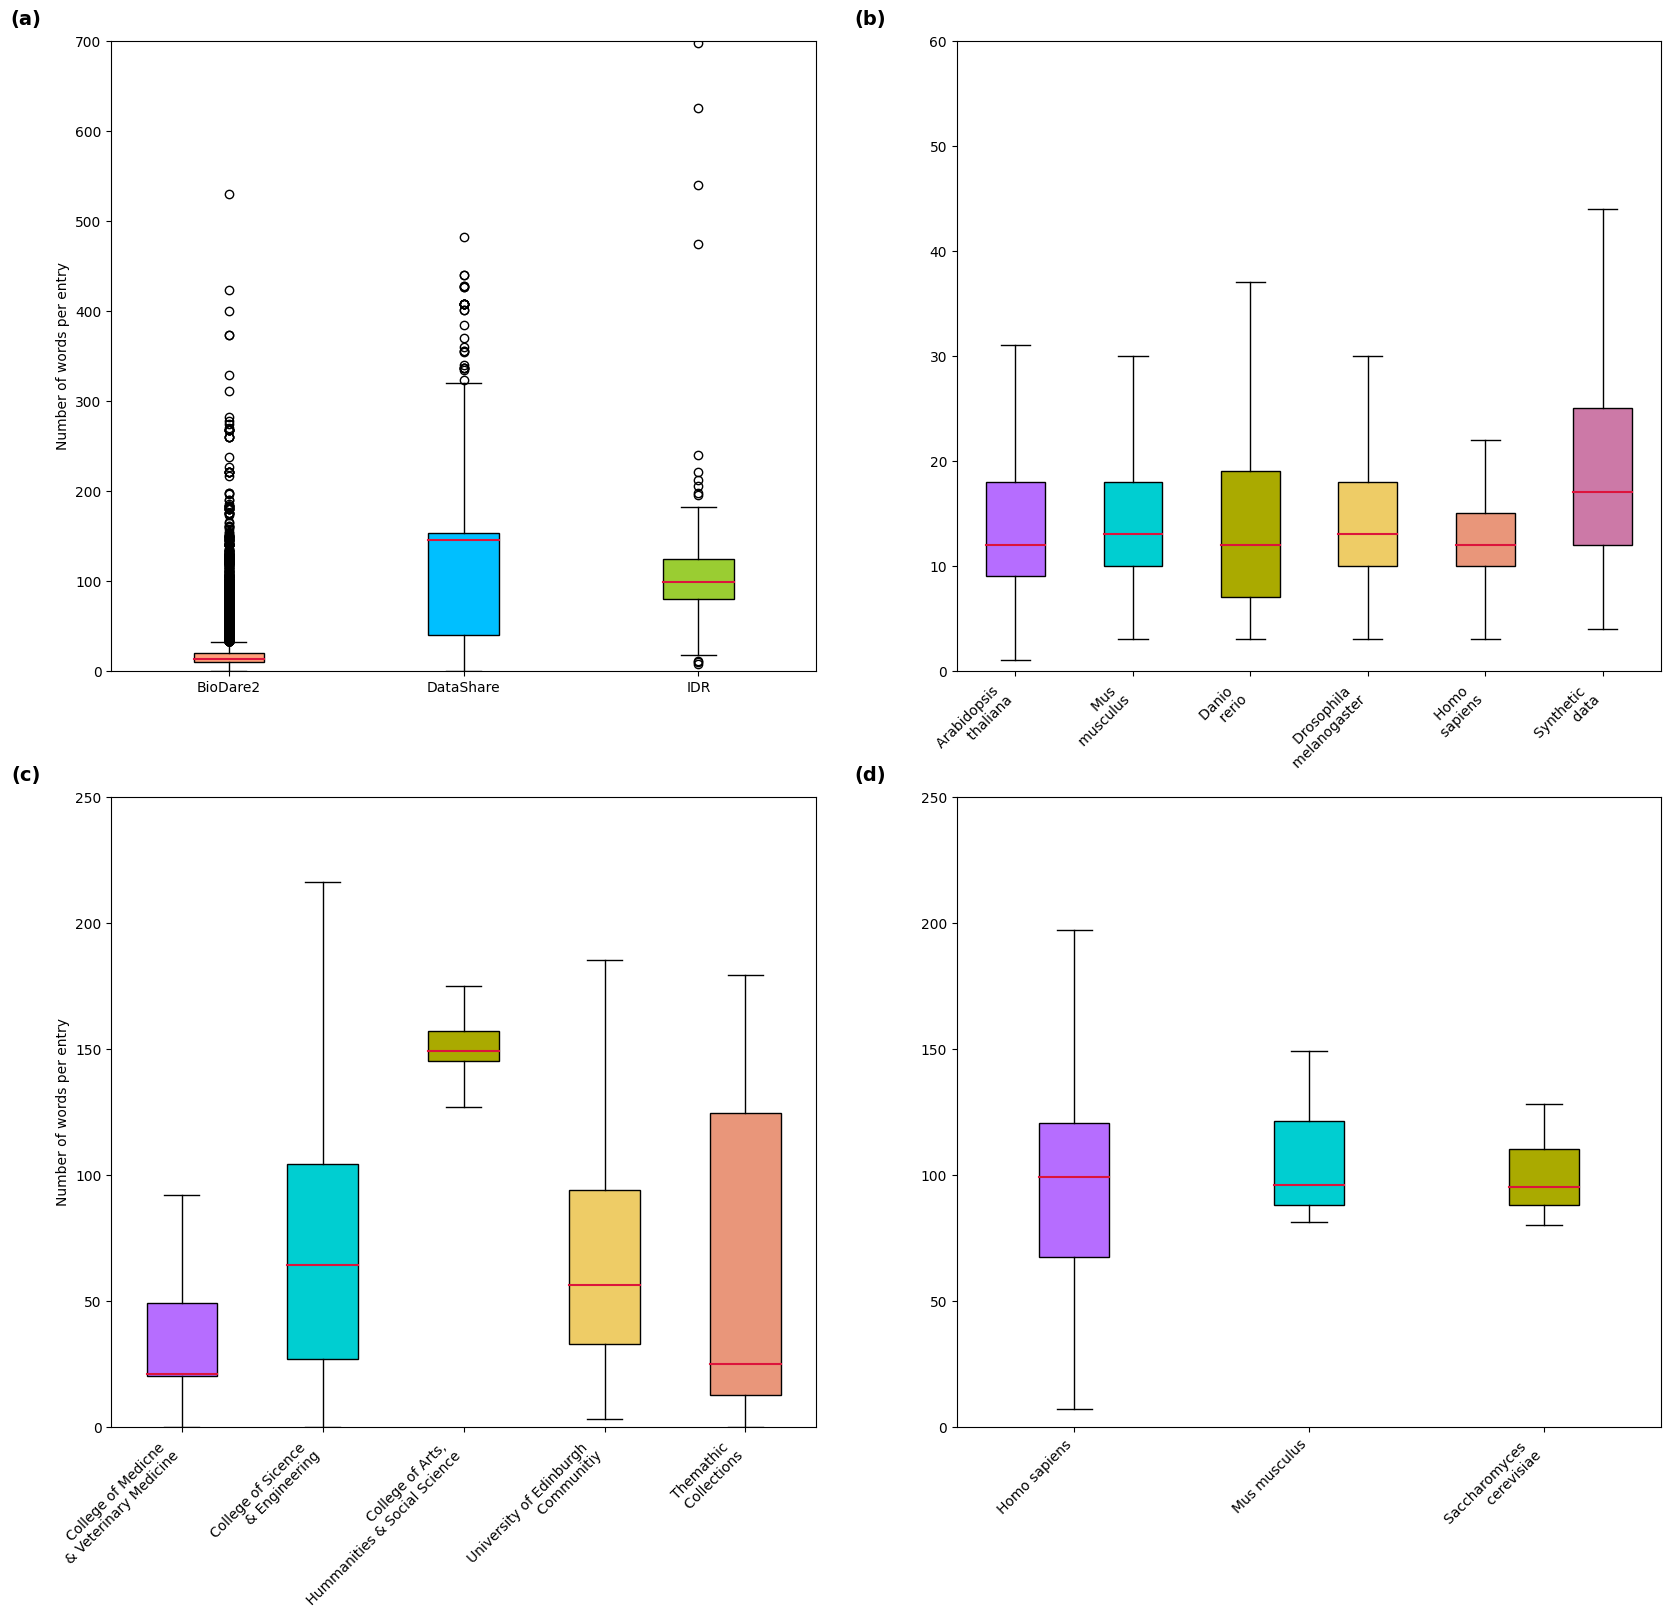

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(20, 18))

# Panel 1
bxplot1 = axes[0,0].boxplot([list_global_biodare2, list_global_datashare, list_global_IDR], medianprops = dict(color = "crimson", linewidth = 1.5), 
           meanline = True, showfliers = True, patch_artist = True, boxprops = dict(facecolor = "powderblue"))

colors = ['lightsalmon', 'deepskyblue', 'yellowgreen']

for patch, color in zip(bxplot1['boxes'], colors):
        patch.set_facecolor(color)


#axes[0,0].set_title('Distributions of number of words in all fields')
axes[0,0].set_xticklabels(['BioDare2', 'DataShare', 'IDR'])
#axes[0,0].set_xlabel('BioDare version')
axes[0,0].set_ylabel('Number of words per entry')

# Panel 2
bxplot2 = axes[0,1].boxplot([list_global_arabidopsis_biodare2, list_global_mus_biodare2, list_global_danio_biodare2,
                              list_global_drosophila_biodare2, list_global_homo_biodare2, list_global_synthetic_biodare2], medianprops = dict(color = "crimson", linewidth = 1.5), 
           meanline = True, showfliers = False, patch_artist = True, boxprops = dict(facecolor = "powderblue"))


colors = ['#B66DFF', 'darkturquoise', '#AAAA00', '#EECC66', 'darksalmon', '#CC79A7']

for patch, color in zip(bxplot2['boxes'], colors):
        patch.set_facecolor(color)

#axes[0,1].set_title('Distributions of number of words in all fields')
axes[0,1].set_xticklabels(['Arabidopsis \n thaliana', 'Mus \n musculus', 'Danio \n rerio', 'Drosophila \n melanogaster', 'Homo \n sapiens', 'Synthetic \n data'], rotation = 45, ha ='right')
#axes[0,1].set_xlabel('BioDare version')


# Panel 3

bxplot3 = axes[1,0].boxplot([list_global_medicine_datashare, list_global_science_datashare, list_global_arts_datashare,
                              list_global_support_datashare, list_global_thematic_datashare ], medianprops = dict(color = "crimson", linewidth = 1.5), 
           meanline = True, showfliers = False, patch_artist = True, boxprops = dict(facecolor = "powderblue"))


colors = ['#B66DFF', 'darkturquoise', '#AAAA00', '#EECC66', 'darksalmon', '#CC79A7']

for patch, color in zip(bxplot3['boxes'], colors):
        patch.set_facecolor(color)

#axes[0,1].set_title('Distributions of number of words in all fields')
axes[1,0].set_xticklabels(['College of Medicne \n & Veterinary Medicine', 'College of Sicence \n & Engineering', 'College of Arts, \n Hummanities & Social Science',
                            'University of Edinburgh \n Communitiy', 'Themathic \n Collections'], rotation = 45, ha ='right')
axes[1,0].set_ylabel('Number of words per entry')



# Panel 4
bxplot4 = axes[1,1].boxplot([list_global_homo_IDR, list_global_mus_IDR, list_global_cerevisiae_IDR], medianprops = dict(color = "crimson", linewidth = 1.5), 
           meanline = True, showfliers = False, patch_artist = True, boxprops = dict(facecolor = "powderblue"))

colors = ['#B66DFF', 'darkturquoise', '#AAAA00', '#EECC66', 'darksalmon', '#CC79A7']
for patch, color in zip(bxplot4['boxes'], colors):
        patch.set_facecolor(color)

#axes[0,1].set_title('Distributions of number of words in all fields')

axes[1,1].set_xticklabels(['Homo sapiens', 'Mus musculus', 'Saccharomyces \n cerevisiae'], rotation = 45, ha ='right')



axes[0, 0].set_ylim(0, 700)   # ✅ Only affects top-left panel
axes[0, 1].set_ylim(0, 60)   # ✅ Only affects top-right panel
axes[1, 0].set_ylim(0, 250)   # ✅ Only affects bottom-left panel
axes[1, 1].set_ylim(0, 250)   # ✅ Only affects bottom-right panel

for ax, label in zip(axes.flat, ['(a)', '(b)', '(c)', '(d)']):
    ax.text(
        -0.1, 1.05,          # x, y position (in axis coordinates)
        label,               # the label
        transform=ax.transAxes,
        fontsize=14,
        fontweight='bold',
        va='top',
        ha='right'
    )



plt.savefig("Figure1_word_counts_20260804.pdf", dpi=300, bbox_inches="tight")   # vector — best for publications
plt.savefig("Figure1_word_counts_20260804.tiff", dpi=300, bbox_inches="tight")  # often required by journals
plt.savefig("Figure1_word_counts_20260804.svg", dpi=300, bbox_inches="tight")   # editable vector


### Figure 3 - Information density

##### BioDare2

In [14]:
s = df_biodare2["ratio_entities_per_word"]

bins_df2 = np.arange(0, 1.0 + 0.1, 0.1)  # 0 to 1 in steps of 0.1
df_biodare2["ratio_bin"] = pd.cut(s, bins=bins_df2, include_lowest=True)

bin_counts_bd2 = df_biodare2["ratio_bin"].value_counts(sort=False)
bin_counts_bd2

ratio_bin
(-0.001, 0.1]     239
(0.1, 0.2]       2043
(0.2, 0.3]       4894
(0.3, 0.4]       6533
(0.4, 0.5]       4694
(0.5, 0.6]       1280
(0.6, 0.7]        538
(0.7, 0.8]        216
(0.8, 0.9]         18
(0.9, 1.0]         14
Name: count, dtype: int64

In [15]:
counts_per_bin_bd2  = df_biodare2["ratio_bin"].value_counts(sort=False)
percent_per_bin_bd2  = df_biodare2["ratio_bin"].value_counts(sort=False, normalize=True) * 100

summary_bd2 = pd.DataFrame({
    "count": counts_per_bin_bd2,
    "percent": percent_per_bin_bd2.round(2)
})

summary_bd2 

,count,percent
ratio_bin,,
"(-0.001, 0.1]",239,1.17
"(0.1, 0.2]",2043,9.98
"(0.2, 0.3]",4894,23.91
"(0.3, 0.4]",6533,31.92
"(0.4, 0.5]",4694,22.93
"(0.5, 0.6]",1280,6.25
"(0.6, 0.7]",538,2.63
"(0.7, 0.8]",216,1.06
"(0.8, 0.9]",18,0.09


In [16]:
dfs_biodare2 = {val: grp.copy() for val, grp in df_biodare2.groupby("species")}

In [17]:
df_arabidopsis_bd2 = dfs_biodare2["arabidopsis thaliana"]
df_mus_bd2 = dfs_biodare2["mus musculus"]
df_danio_bd2 = dfs_biodare2["danio rerio"]
df_drosophila_bd2 = dfs_biodare2["drosophila melanogaster"]
df_homo_bd2 = dfs_biodare2["homo sapiens"]
df_synthetic_bd2 = dfs_biodare2["synthetic data"]

In [18]:
communities_bd2 = ["Arabidopsis \n thaliana", "Mus \n musculus", "Danio \n rerio", "Drosophila \n melanogaster", "Homo \n sapiens", "Synthetic \n data"]

dfs_ratios_bd2 = {
    "Arabidopsis thaliana": df_arabidopsis_bd2,
    "Mus musculus": df_mus_bd2,
    "Danio rerio": df_danio_bd2,
    "Drosophila melanogaster": df_drosophila_bd2,
    "Homo sapiens": df_homo_bd2,
    "Synthetic data": df_synthetic_bd2
    
}

dic_ratios_bd2 = {}

for community, df in dfs_ratios_bd2.items():
    dic_ratios_bd2[community] = df_ratios_per_community(df)

In [19]:
dic_ratios_bd2

{'Arabidopsis thaliana':                count  percent
 ratio_bin                    
 (-0.001, 0.1]     80     1.14
 (0.1, 0.2]       581     8.24
 (0.2, 0.3]      1788    25.37
 (0.3, 0.4]      2315    32.85
 (0.4, 0.5]      1718    24.38
 (0.5, 0.6]       364     5.16
 (0.6, 0.7]       144     2.04
 (0.7, 0.8]        50     0.71
 (0.8, 0.9]         3     0.04
 (0.9, 1.0]         5     0.07,
 'Mus musculus':                count  percent
 ratio_bin                    
 (-0.001, 0.1]     26     0.74
 (0.1, 0.2]       364    10.39
 (0.2, 0.3]       861    24.59
 (0.3, 0.4]      1186    33.87
 (0.4, 0.5]       695    19.85
 (0.5, 0.6]       237     6.77
 (0.6, 0.7]        88     2.51
 (0.7, 0.8]        42     1.20
 (0.8, 0.9]         3     0.09
 (0.9, 1.0]         0     0.00,
 'Danio rerio':                count  percent
 ratio_bin                    
 (-0.001, 0.1]     16     0.89
 (0.1, 0.2]       138     7.70
 (0.2, 0.3]       310    17.29
 (0.3, 0.4]       494    27.55
 (0.4, 0.5]  

In [20]:
arabidopsis_percentage_bd2 = dic_ratios_bd2["Arabidopsis thaliana"]["percent"].to_numpy().tolist()
mus_percentage_bd2 = dic_ratios_bd2["Mus musculus"]["percent"].to_numpy().tolist()
danio_percentage_bd2 = dic_ratios_bd2["Danio rerio"]["percent"].to_numpy().tolist()
drosophila_percentage_bd2 = dic_ratios_bd2["Drosophila melanogaster"]["percent"].to_numpy().tolist()
homo_percentage_bd2 = dic_ratios_bd2["Homo sapiens"]["percent"].to_numpy().tolist()
synthetic_percentage_bd2 = dic_ratios_bd2["Synthetic data"]["percent"].to_numpy().tolist()

In [21]:
data_bd2 = [arabidopsis_percentage_bd2, mus_percentage_bd2, danio_percentage_bd2, drosophila_percentage_bd2, homo_percentage_bd2, synthetic_percentage_bd2]
values_bd2 = dic_ratios_bd2["Homo sapiens"]["percent"].index.astype(str).tolist()

##### DataShare

In [22]:
s = df_datashare["ratio_entities_per_word"]

bins_datashare = np.arange(0, 1.0 + 0.1, 0.1)  # 0 to 1 in steps of 0.1
df_datashare["ratio_bin"] = pd.cut(s, bins=bins_datashare, include_lowest=True)

bin_counts_datashare = df_datashare["ratio_bin"].value_counts(sort=False)
bin_counts_datashare

ratio_bin
(-0.001, 0.1]       5
(0.1, 0.2]        112
(0.2, 0.3]       5532
(0.3, 0.4]       1786
(0.4, 0.5]        252
(0.5, 0.6]         15
(0.6, 0.7]          5
(0.7, 0.8]          1
(0.8, 0.9]          0
(0.9, 1.0]          0
Name: count, dtype: int64

In [23]:
counts_per_bin_datashare = df_datashare["ratio_bin"].value_counts(sort=False)
percent_per_bin_datashare = df_datashare["ratio_bin"].value_counts(sort=False, normalize=True) * 100

summary_datashare = pd.DataFrame({
    "count": counts_per_bin_datashare,
    "percent": percent_per_bin_datashare.round(2)
})

summary_datashare

,count,percent
ratio_bin,,
"(-0.001, 0.1]",5,0.06
"(0.1, 0.2]",112,1.45
"(0.2, 0.3]",5532,71.77
"(0.3, 0.4]",1786,23.17
"(0.4, 0.5]",252,3.27
"(0.5, 0.6]",15,0.19
"(0.6, 0.7]",5,0.06
"(0.7, 0.8]",1,0.01
"(0.8, 0.9]",0,0.00


In [24]:
dfs_datashare = {val: grp.copy() for val, grp in df_datashare.groupby("community")}

In [25]:
df_arts_datashare = dfs_datashare["Arts"]
df_medicine_datashare = dfs_datashare["Medicine"]
df_science_datashare = dfs_datashare["Science"]
df_support_datashare = dfs_datashare["Support"]
df_thematic_datashare = dfs_datashare["Thematic"]

In [26]:
communities_datashare = ["College of Arts, \n Hummanities & \n Social Science", "College of Science \n & Engineering", "College of Medicine \n & Veterinary Medicine", "University of Edinburgh \n Community", "Thematic \n Collections"]

dfs_ratios_datashare = {
    "arts": df_arts_datashare,
    "science": df_science_datashare,
    "medicine": df_medicine_datashare,
    "support": df_support_datashare,
    "thematic": df_thematic_datashare
}

dic_ratios_datashare = {}

for community, df in dfs_ratios_datashare.items():
    dic_ratios_datashare[community] = df_ratios_per_community(df)

In [27]:
arts_percentage = dic_ratios_datashare["arts"]["percent"].to_numpy().tolist()
medicine_percentage = dic_ratios_datashare["medicine"]["percent"].to_numpy().tolist()
science_percentage = dic_ratios_datashare["science"]["percent"].to_numpy().tolist()
support_percentage = dic_ratios_datashare["support"]["percent"].to_numpy().tolist()
thematic_percentage = dic_ratios_datashare["thematic"]["percent"].to_numpy().tolist()

In [28]:
data_datashare = [arts_percentage, medicine_percentage, science_percentage, support_percentage, thematic_percentage]
values_datashare = dic_ratios_datashare["arts"]["percent"].index.astype(str).tolist()

#### IDR

In [29]:
s = df_IDR["ratio_entities_per_word"]

bins_IDR = np.arange(0, 1.0 + 0.1, 0.1)  # 0 to 1 in steps of 0.1
df_IDR["ratio_bin"] = pd.cut(s, bins=bins_IDR, include_lowest=True)

bin_counts_IDR = df_IDR["ratio_bin"].value_counts(sort=False)
bin_counts_IDR

ratio_bin
(-0.001, 0.1]     0
(0.1, 0.2]        0
(0.2, 0.3]       29
(0.3, 0.4]       88
(0.4, 0.5]       13
(0.5, 0.6]        2
(0.6, 0.7]        0
(0.7, 0.8]        0
(0.8, 0.9]        0
(0.9, 1.0]        0
Name: count, dtype: int64

In [30]:
counts_per_bin_IDR = df_IDR["ratio_bin"].value_counts(sort=False)
percent_per_bin_IDR = df_IDR["ratio_bin"].value_counts(sort=False, normalize=True) * 100

summary_IDR = pd.DataFrame({
    "count": counts_per_bin_IDR,
    "percent": percent_per_bin_IDR.round(2)
})

summary_IDR

,count,percent
ratio_bin,,
"(-0.001, 0.1]",0,0.00
"(0.1, 0.2]",0,0.00
"(0.2, 0.3]",29,21.97
"(0.3, 0.4]",88,66.67
"(0.4, 0.5]",13,9.85
"(0.5, 0.6]",2,1.52
"(0.6, 0.7]",0,0.00
"(0.7, 0.8]",0,0.00
"(0.8, 0.9]",0,0.00


In [31]:
dfs_IDR = {val: grp.copy() for val, grp in df_IDR.groupby("Study_Organism")}

In [32]:
df_homo_IDR = dfs_IDR["homo sapiens"]
df_mus_IDR = dfs_IDR["mus musculus"]
df_cerevisiae_IDR = dfs_IDR["saccharomyces cerevisiae"]

In [33]:
communities_IDR = ["Homo \n sapiens", "Mus \n musculus", "Saccharomyces \n cerevisiae"]

dfs_ratios_IDR  = {
    "homo sapiens": df_homo_IDR,
    "mus musculus": df_mus_IDR,
    "saccharomyces cerevisiae": df_cerevisiae_IDR 
}


dic_ratios_IDR = {}

for community, df in dfs_ratios_IDR.items():
    dic_ratios_IDR[community] = df_ratios_per_community(df)

In [34]:
homo_percentage = dic_ratios_IDR["homo sapiens"]["percent"].to_numpy().tolist()
mus_percentage = dic_ratios_IDR["mus musculus"]["percent"].to_numpy().tolist()
cerevisiae_percentage = dic_ratios_IDR["saccharomyces cerevisiae"]["percent"].to_numpy().tolist()

In [35]:
data_IDR = [homo_percentage, mus_percentage, cerevisiae_percentage]
values_IDR = dic_ratios_IDR["homo sapiens"]["percent"].index.astype(str).tolist()

### All together graph

In [36]:
#palette = cm.RdPu(np.linspace(0.1, 0.9, 10)) ## Very pink :)
palette = cm.RdYlGn_r(np.linspace(0.1, 0.9, 10))

In [37]:
def stacked_bar_panel(ax, *, data, communities, values, title,
                      palette, bar_width=0.5, label_threshold=2, ylim=(0, 100)):
    data = np.asarray(data)
    if data.shape != (len(communities), len(values)):
        raise ValueError(
            f"Shape mismatch for '{title}': data.shape={data.shape} "
            f"expected ({len(communities)}, {len(values)})"
        )

    index = np.arange(len(communities))
    bottom = np.zeros(len(communities), dtype=float)

    for i, v in enumerate(values):
        bars = ax.bar(
            index, data[:, i], bar_width,
            bottom=bottom,
            color=palette[i % len(palette)],
            label=v
        )

        for j, b in enumerate(bars):
            h = b.get_height()
            if h < label_threshold:
                continue
            x = b.get_x() + b.get_width() / 2
            y = bottom[j] + h / 2
            ax.text(x, y, f"{h:.1f}%", ha="center", va="center",
                    fontsize=16, color="black")

        bottom += data[:, i]

    ax.set_title(title, fontsize=24)
    ax.set_ylabel("Entities (%)", fontsize=18)
    ax.set_xticks(index)
    ax.tick_params(axis="y", labelsize=18)
    ax.tick_params(axis="x", labelsize=18)
    ax.set_xticklabels(communities, rotation=45, ha="right", fontsize=18)
    ax.set_ylim(*ylim)
    ax.margins(y=0)
    ax.grid(axis="y", alpha=0.2)

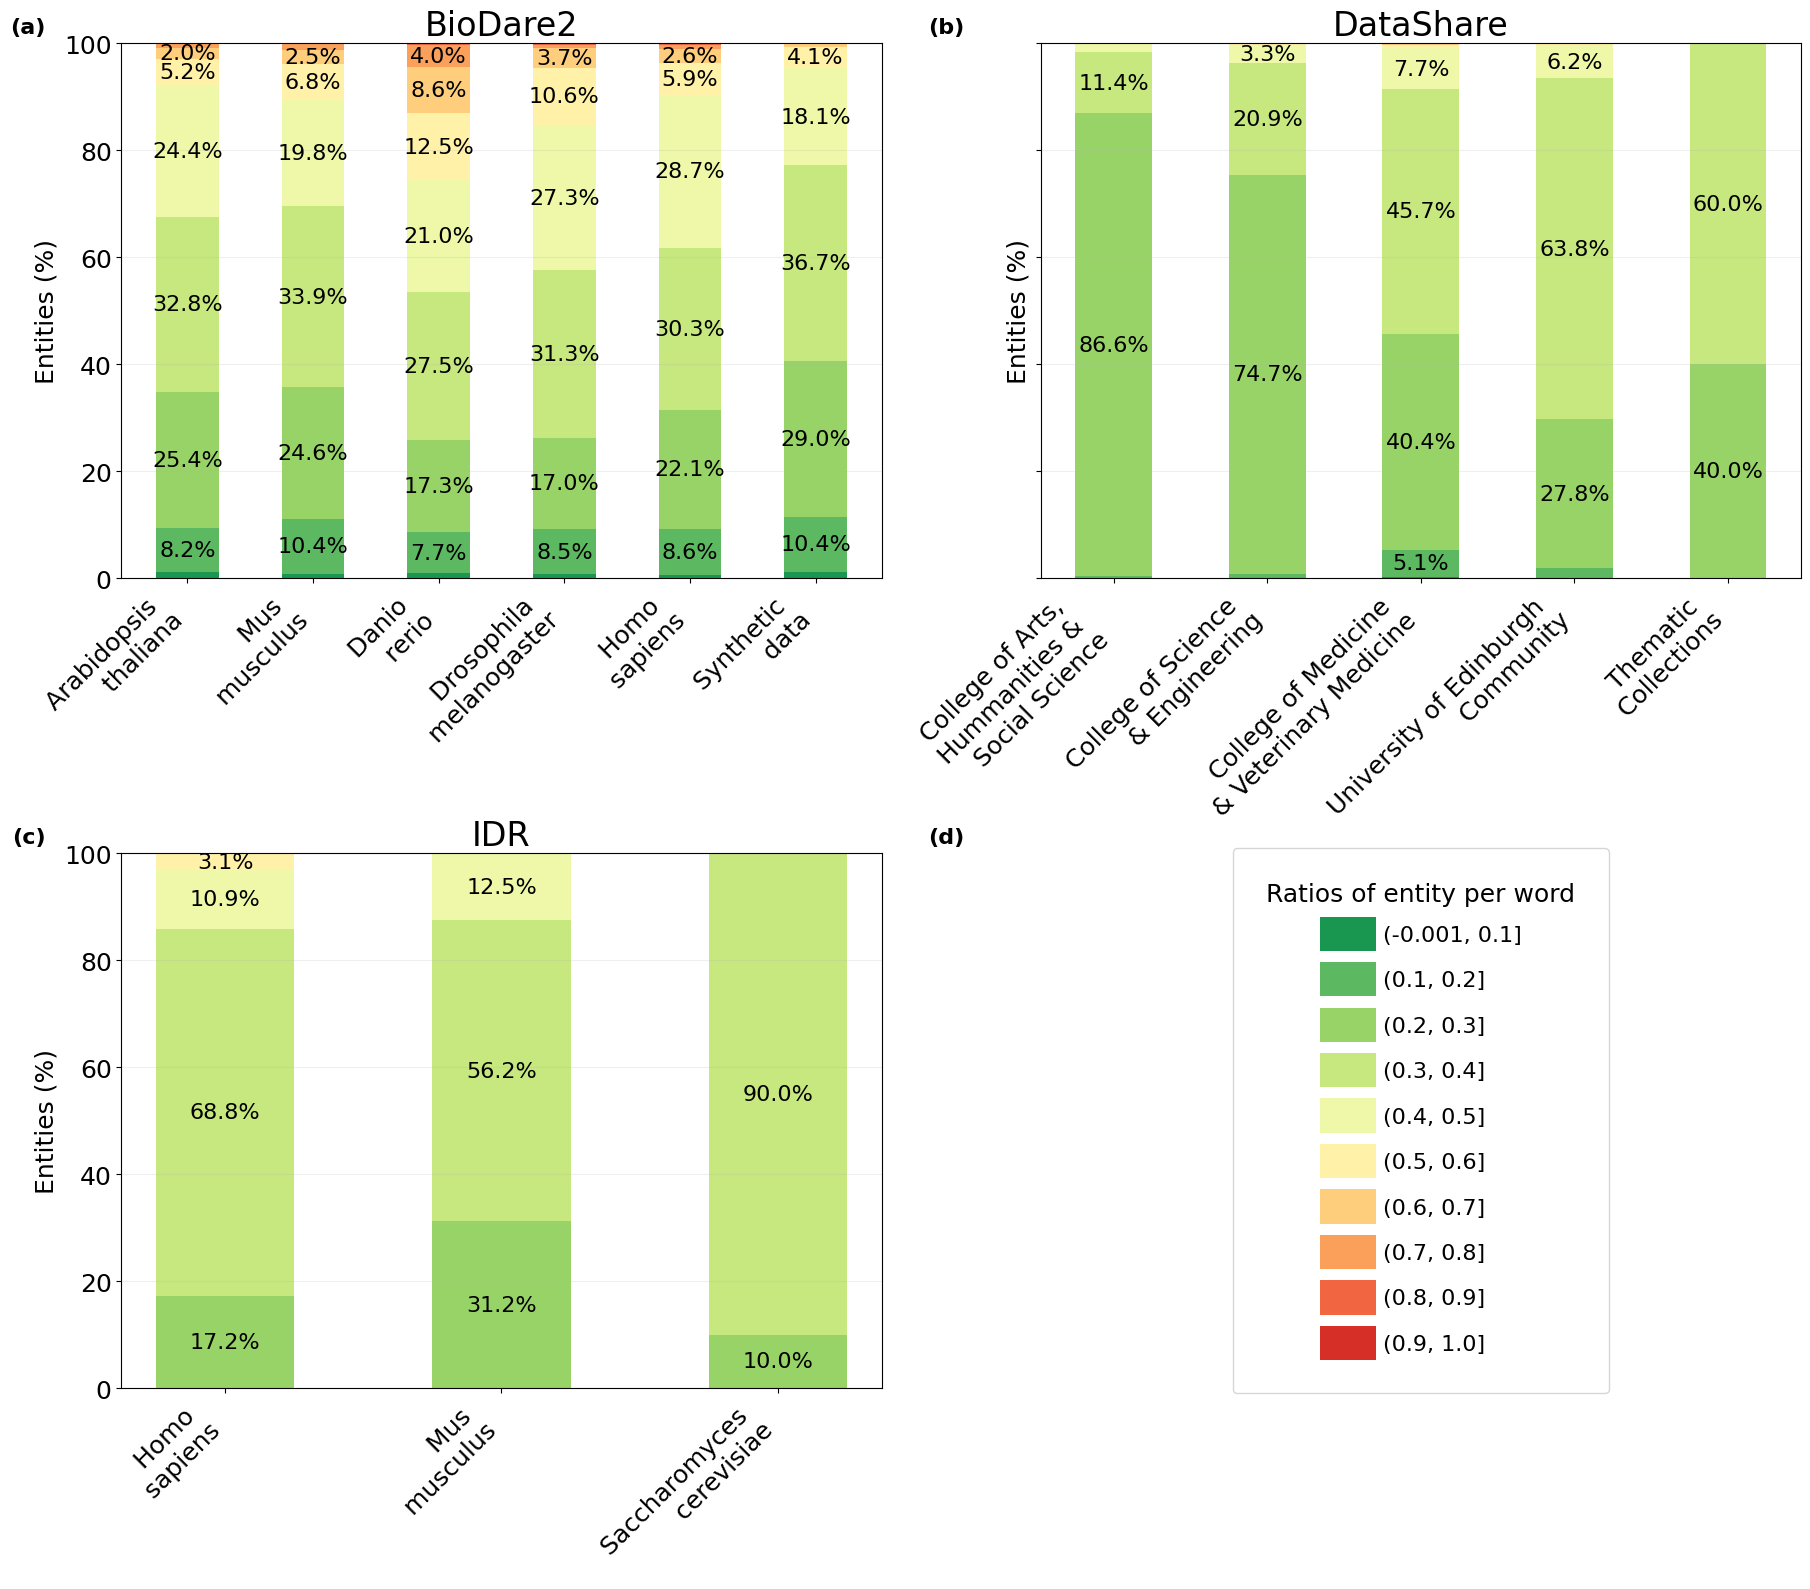

In [38]:
fig, axs = plt.subplots(2, 2, figsize=(18, 16), sharey=True)
axs = axs.ravel()

stacked_bar_panel(
    axs[0],
    data=data_bd2, communities=communities_bd2 , values=values_bd2,
    title="BioDare2", palette=palette
)

stacked_bar_panel(
    axs[1],
    data=data_datashare, communities=communities_datashare, values=values_datashare,
    title="DataShare", palette=palette
)

stacked_bar_panel(
    axs[2],
    data=data_IDR, communities=communities_IDR, values=values_IDR,
    title="IDR", palette=palette
)

# ---- 4th panel used for legend only ----
ax_leg = axs[3]
ax_leg.axis("off")
#ax_leg.set_title("Legend", fontsize=16)

# Choose what the legend should represent:
# If all three charts share the same values, use that list.
# If they differ, either pick one or build a combined list.
values_for_legend = values_bd2  # or values2 / values3, or combine (see below)

handles = [
    Patch(facecolor=palette[i % len(palette)], label=v)
    for i, v in enumerate(values_for_legend)
]

ax_leg.legend(
    handles=handles,
    loc="center",
    title="Ratios of entity per word",
    title_fontsize=18,    # ⬆️ bigger title
    frameon=True,
    ncol=1,
    fontsize=16,          # ⬆️ bigger labels
    handlelength=2.5,     # ⬆️ wider colour box
    handleheight=2.0,     # ⬆️ taller colour box
    borderpad=1.5,        # ⬆️ padding inside the legend box
    labelspacing=0.5,     # ⬆️ vertical space between entries
    handletextpad=0.3     # ⬆️ space between box and text
)


fig.tight_layout()

# Label all 4 panels including the legend
for ax, label in zip(axs, ['(a)', '(b)', '(c)', '(d)']):
    ax.text(
        -0.1, 1.05, label,
        transform=ax.transAxes,
        fontsize=16,
        fontweight='bold',
        va='top', ha='right'
    )



plt.savefig("Figure3_informaiton_density_20260804.pdf", dpi=300, bbox_inches="tight")   # vector — best for publications
plt.savefig("Figure3_informaiton_density_20260804.tiff", dpi=300, bbox_inches="tight")  # often required by journals
plt.savefig("Figure3_informaiton_density_20260804.svg", dpi=300, bbox_inches="tight")   # editable vector



### Figure 4 - Rarefaction curve

In [39]:
df_IDR

,Unnamed: 0.1,Unnamed: 0,Comment[IDR_Study_Accession],Study_Title,Study_Type,Study_Type_Term_Source_REF,Study_Type_Term_Accession,Study_Description,Study_Key_Words,Study_Organism,...,Experiment_Description_clean_entities,all_entities,entities,entities_counter,entities_count,unique_entities_count,all_entities_clean_entities_white_spaces,global_counts,ratio_entities_per_word,ratio_bin
0,0,0,idr0092,a semi-automated organoid screening method dem...,compound library screen,efo,efo_0007553,intestinal organoids are an excellent model to...,organoids,mus musculus,...,[],"['[intestinal, model study, epithelial biology...","[""['[intestinal"", ' model study', ' epithelial...","{""['[intestinal"": 1, ' model study': 1, ' epit...",35,30,"['[', '[intestinal,', 'model', 'study,', 'epit...",89,0.393258,"(0.3, 0.4]"
1,1,1,idr0016,human u2os cells - compound cell-painting expe...,high content screen,efo,efo_0007550,phenotypic profiling attempts to summarize mul...,NaN,homo sapiens,...,[],"['[phenotypic profiling, multiparametric analy...","[""['[phenotypic profiling"", ' multiparametric ...","{""['[phenotypic profiling"": 1, ' multiparametr...",58,49,"['[', '[phenotypic', 'profiling,', 'multiparam...",182,0.318681,"(0.3, 0.4]"
2,2,2,idr0079,an image-based data-driven analysis of cellula...,microscopy assay,efo,efo_0002909,a data-driven analysis of cell morphology and ...,image analysis,danio rerio,...,"[confocal imaging, posterior lateral line, pri...","['[morphology, intracellular, organization, ze...","[""['[morphology"", ' intracellular', ' organiza...","{""['[morphology"": 1, ' intracellular': 2, ' or...",30,27,"['[', '[morphology,', 'intracellular,', 'organ...",80,0.375000,"(0.3, 0.4]"
3,3,3,idr0067,meiotic cellular rejuvenation is coupled to nu...,time-lapse imaging,omit,omit_0027490,production of healthy gametes in meiosis relie...,meiosis,saccharomyces cerevisiae\n,...,"[cell fluorescence microscopy, image, yeast, m...","['[production, healthy, meiosis, quality, dist...","[""['[production"", ' healthy', ' meiosis', ' qu...","{""['[production"": 1, ' healthy': 1, ' meiosis'...",40,35,"['[', '[production,', 'healthy,', 'meiosis,', ...",128,0.312500,"(0.3, 0.4]"
4,4,4,idr0134,reference bioimaging dataset to assess the phe...,histology,none,none,"here, we present a high-quality reference data...",phenotypes,diplophyllum albicans,...,"[specimen, herbaria, sample diplophyllum taxif...","['[dataset, macroscopic, phenotypic property s...","[""['[dataset"", ' macroscopic', ' phenotypic pr...","{""['[dataset"": 1, ' macroscopic': 2, ' phenoty...",148,109,"['[', '[dataset,', 'macroscopic,', 'phenotypic...",540,0.274074,"(0.2, 0.3]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,127,127,idr0023,nuclear pore scaffold structure analyzed by su...,protein localization,efo,go:0008104,much of life's essential molecular machinery c...,NaN,homo sapiens,...,"[systematic immunolabelling, complex, monomeri...","['[lifes, molecular machinery, protein assembl...","[""['[lifes"", ' molecular machinery', ' protein...","{""['[lifes"": 1, ' molecular machinery': 1, ' p...",27,27,"['[', '[lifes,', 'molecular', 'machinery,', 'p...",86,0.313953,"(0.3, 0.4]"
128,128,128,idr0038,ex vivo live cell tracking in kidney organoids...,time-lapse imaging,omit,omit_0027490,we have adapted the mouse kidney rudiment assa...,NaN,mus musculus,...,"[adapt, mouse kidney rudiment assay, renal org...","['[adapt, mouse kidney rudiment assay, renal o...","[""['[adapt"", ' mouse kidney rudiment assay', '...","{""['[adapt"": 1, ' mouse kidney rudiment assay'...",60,52,"['[', '[adapt,', 'mouse', 'kidney', 'rudiment'...",240,0.250000,"(0.2, 0.3]"
129,129,129,idr0138,integration of spatial and single-cell transcr...,seqfish,efo,efo_0008991,molecular profiling of single cells has advanc...,seqfish,mus musculus,...,"[seqfish study, sagittal section, mouse, embry...","['[molecular profiling, single cell advance, d...","[""['[molecular profiling"", ' 

In [40]:
def accumative_counts(df, column_id_name):
    accumulative_data_df = pd.DataFrame(columns=['id_modified', 'Accumulative_count_entities'])
    
    unique_entities = set()  # ✅ Initialise ONCE outside the loop

    for idx, i in df.iterrows():
        entities = i['entities']

        flat_entities = [str(entity) for sublist in entities for entity in sublist]
        clean_entities = [item.replace('[', '').replace(']', '') for item in flat_entities]
        
        unique_entities.update(clean_entities)  # ✅ Just ADD new items to existing set
        accumulative_count = len(unique_entities)

        accumulative_data_df.at[idx, 'id_modified'] = str(i[column_id_name]) + '_BD'
        accumulative_data_df.at[idx, 'Accumulative_count_entities'] = accumulative_count

    return accumulative_data_df


In [41]:
accumative_counts_biodare2 = accumative_counts(df_biodare2, 'id')

In [42]:
accumative_counts_datashare = accumative_counts(df_datashare, 'id_in_file')

In [43]:
accumative_counts_IDR = accumative_counts(df_IDR, 'Comment[IDR_Study_Accession]')

#### Figure 4 - option 1

In [44]:
import ast
combined_list_biodare2 = df_biodare2['all_entities'].explode().tolist()
combined_list = []
for item in combined_list_biodare2:
    list_items = ast.literal_eval(item)
    first_list = list_items[0].strip('[]').split(', ')
    combined_list.extend(first_list)

print(combined_list)

['control', '', 'ld lhy', 'lhy long marker', 'lhy long marker', 'lhy long marker', 'check', 'version', '', '', 'leaf', 'movement', '', 'platereader', 'lhy mutant', 'testing', 'version', 'update', 'oscillation', 'user process', '', '', '', 'complementation', 'translational fusion', 'arabidopsis', 'mutant circadian', 'phenotype', 'effect', 'growth benzimidazole', 'clock', 'phenotype', 'humidity', 'oscillation', 'core', 'gene lhy', '', 'napus', 'testing', 'clustering', 'brassica blank', 'clustiere paper', 'complementation', 'complementation', 'nitrate', 'circadian', 'clock', 'nitrate', 'horloge', 'circadian', 'clock', 'biotech', 'circadian', 'clock', 'nitrate testing', 'circadian', 'clock', 'nitrate', 'circadian', 'clock', 'nitrate', 'circadian', 'clock test', '', 'delay', '', '', 'tsete blue light', 'testing', 'testing', 'testing', 'circadian', 'clock', 'nitrate experiment', 'luciferase', 'luciferase', 'selection', 'tsete red light', '', '', 'selection complementation line', 'nitrate', '

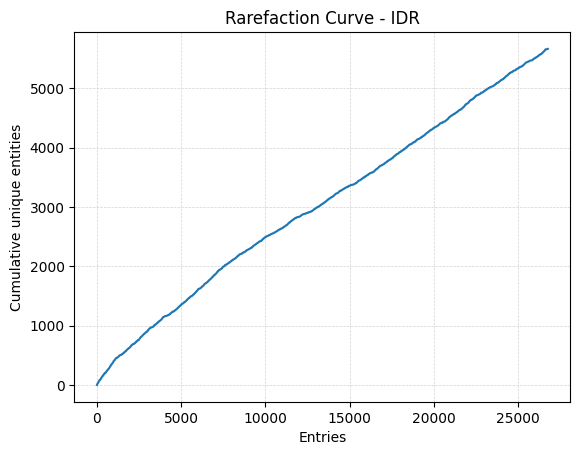

In [45]:
import matplotlib.pyplot as plt

# Flat list of all entities
words = combined_list

# ✅ Maintain a running set instead of rebuilding every iteration
running_set = set()
cumulative_unique_words = []

for word in words:
    running_set.add(word)
    cumulative_unique_words.append(len(running_set))

# Plot the rarefaction curve
plt.plot(range(1, len(words) + 1), cumulative_unique_words)
plt.xlabel("Entries")
plt.ylabel("Cumulative unique entities")
plt.title("Rarefaction Curve - IDR")
plt.grid(True, linestyle='--', linewidth=0.5, color='lightgray')
plt.show()


In [46]:
def compute_rarefaction(word_list):
    running_set = set()
    cumulative = []
    for word in word_list:
        running_set.add(word)
        cumulative.append(len(running_set))
    return cumulative

In [47]:
# ✅ Compute for each dataset
#combined_list_IDR = df_IDR['all_entities'].explode().tolist()
#cumulative_IDR = compute_rarefaction(combined_list_IDR)

combined_list_datashare = df_datashare['entities'].explode().tolist()
cumulative_datashare = compute_rarefaction(combined_list_datashare)

combined_list_biodare2 = df_biodare2['entities'].explode().tolist()
cumulative_biodare2 = compute_rarefaction(combined_list_biodare2)


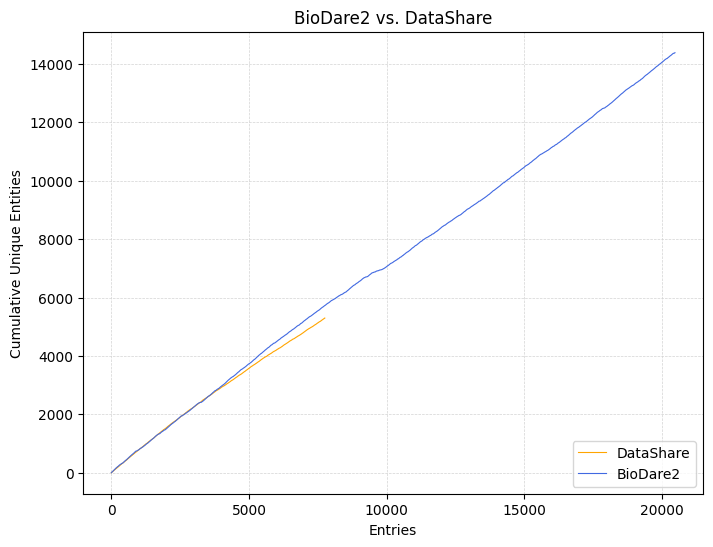

<Figure size 640x480 with 0 Axes>

In [48]:
plt.figure(figsize=(8, 6))


plt.plot(range(1, len(combined_list_datashare) + 1), cumulative_datashare, 
         color='orange', linewidth=0.8, label='DataShare')

plt.plot(range(1, len(combined_list_biodare2) + 1), cumulative_biodare2, 
         color='royalblue', linewidth=0.8, label='BioDare2')

plt.xlabel("Entries")
plt.ylabel("Cumulative Unique Entities")
plt.title("BioDare2 vs. DataShare")
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', linewidth=0.5, color='lightgray')
plt.show()

plt.savefig("Figure4_a_rarefaction_curve_20260811.pdf", dpi=300, bbox_inches="tight")   # vector — best for publications
plt.savefig("Figure4_a_rarefaction_curve_20260811.tiff", dpi=300, bbox_inches="tight")  # often required by journals
plt.savefig("Figure4_a_rarefaction_curve_20260811.svg", dpi=300, bbox_inches="tight")   # editable vector


In [49]:
combined_list_arabidopsis_bd2 = df_arabidopsis_bd2['entities'].explode().tolist()
cumulative_arabidopsis_bd = compute_rarefaction(combined_list_arabidopsis_bd2)

combined_list_mus_bd2 = df_mus_bd2['entities'].explode().tolist()
cumulative_mus_bd = compute_rarefaction(combined_list_mus_bd2)

combined_list_danio_bd2 = df_danio_bd2['entities'].explode().tolist()
cumulative_danio_bd = compute_rarefaction(combined_list_danio_bd2)

combined_list_drosophila_bd2 = df_drosophila_bd2['entities'].explode().tolist()
cumulative_drosophila_bd = compute_rarefaction(combined_list_drosophila_bd2)

combined_list_homo_bd2 = df_homo_bd2['entities'].explode().tolist()
cumulative_homo_bd = compute_rarefaction(combined_list_homo_bd2)

combined_list_synthetic_bd2 = df_synthetic_bd2['entities'].explode().tolist()
cumulative_synthetic_bd = compute_rarefaction(combined_list_synthetic_bd2)

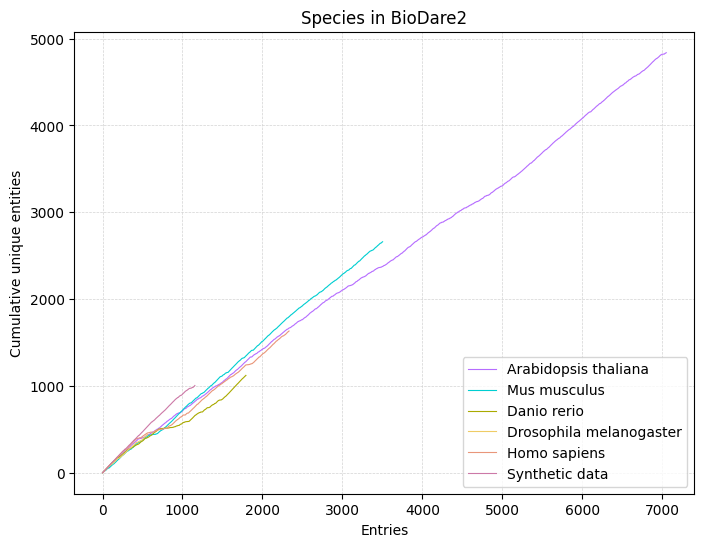

<Figure size 640x480 with 0 Axes>

In [50]:
plt.figure(figsize=(8, 6))


plt.plot(range(1, len(combined_list_arabidopsis_bd2) + 1), cumulative_arabidopsis_bd, 
         color='#B66DFF', linewidth=0.8, label='Arabidopsis thaliana')

plt.plot(range(1, len(combined_list_mus_bd2) + 1), cumulative_mus_bd, 
         color='darkturquoise', linewidth=0.8, label='Mus musculus')

plt.plot(range(1, len(combined_list_danio_bd2) + 1), cumulative_danio_bd, 
         color='#AAAA00', linewidth=0.8, label='Danio rerio')

plt.plot(range(1, len(combined_list_drosophila_bd2) + 1), cumulative_drosophila_bd, 
         color='#EECC66', linewidth=0.8, label='Drosophila melanogaster')

plt.plot(range(1, len(combined_list_homo_bd2) + 1), cumulative_homo_bd, 
         color='darksalmon', linewidth=0.8, label='Homo sapiens')

plt.plot(range(1, len(combined_list_synthetic_bd2) + 1), cumulative_synthetic_bd, 
         color='#CC79A7', linewidth=0.8, label='Synthetic data')


plt.xlabel("Entries")
plt.ylabel("Cumulative unique entities")
plt.title("Species in BioDare2")
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', linewidth=0.5, color='lightgray')
plt.show()


plt.savefig("Figure4_b_rarefaction_curve_20260811.pdf", dpi=300, bbox_inches="tight")   # vector — best for publications
plt.savefig("Figure4_b_rarefaction_curve_20260811.tiff", dpi=300, bbox_inches="tight")  # often required by journals
plt.savefig("Figure4_b_rarefaction_curve_20260811.svg", dpi=300, bbox_inches="tight")   # editable vector

In [51]:
combined_list_arts_ds = df_arts_datashare['entities'].explode().tolist()
cumulative_arts_ds = compute_rarefaction(combined_list_arts_ds)

combined_list_medicine_ds = df_medicine_datashare['entities'].explode().tolist()
cumulative_medicine_ds = compute_rarefaction(combined_list_medicine_ds)

combined_list_science_ds = df_science_datashare['entities'].explode().tolist()
cumulative_science_ds = compute_rarefaction(combined_list_science_ds)

combined_list_support_ds = df_support_datashare['entities'].explode().tolist()
cumulative_support_ds = compute_rarefaction(combined_list_support_ds)

combined_list_thematic_ds = df_thematic_datashare['entities'].explode().tolist()
cumulative_thematic_ds = compute_rarefaction(combined_list_thematic_ds)


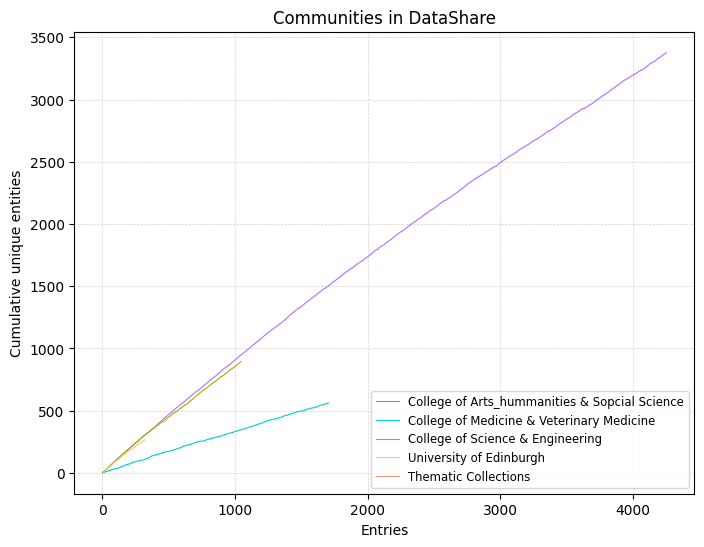

<Figure size 640x480 with 0 Axes>

In [52]:
plt.figure(figsize=(8, 6))


plt.plot(range(1, len(combined_list_arts_ds) + 1), cumulative_arts_ds, 
         color='#B66DFF', linewidth=0.8, label='College of Arts_hummanities & Sopcial Science')

plt.plot(range(1, len(combined_list_medicine_ds) + 1), cumulative_medicine_ds, 
         color='darkturquoise', linewidth=0.8, label='College of Medicine & Veterinary Medicine')

plt.plot(range(1, len(combined_list_science_ds) + 1), cumulative_science_ds, 
         color='#AAAA00', linewidth=0.8, label='College of Science & Engineering')

plt.plot(range(1, len(combined_list_support_ds) + 1), cumulative_support_ds, 
         color='#EECC66', linewidth=0.8, label='University of Edinburgh')

plt.plot(range(1, len(combined_list_thematic_ds) + 1), cumulative_thematic_ds, 
         color='darksalmon', linewidth=0.8, label='Thematic Collections')


plt.xlabel("Entries")
plt.ylabel("Cumulative unique entities")
plt.title("Communities in DataShare")
plt.legend(loc='lower right', fontsize='small')
plt.grid(True, linestyle='--', linewidth=0.5, color='lightgray')
plt.show()

plt.savefig("Figure4_c_rarefaction_curve_20260811.pdf", dpi=300, bbox_inches="tight")   # vector — best for publications
plt.savefig("Figure4_c_rarefaction_curve_20260811.tiff", dpi=300, bbox_inches="tight")  # often required by journals
plt.savefig("Figure4_c_rarefaction_curve_20260811.svg", dpi=300, bbox_inches="tight")   # editable vector

#### Figure 4 - option 2

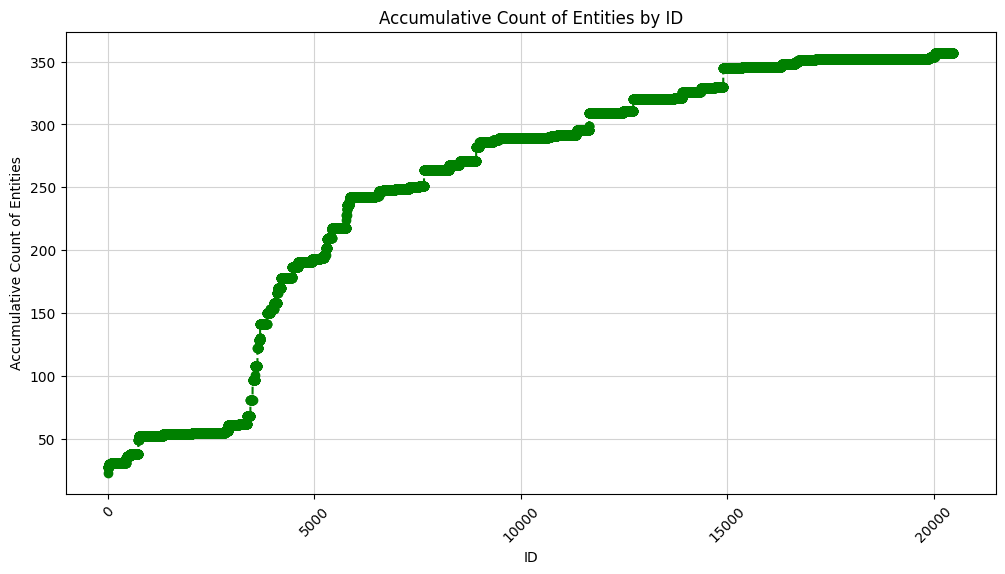

In [53]:
plt.figure(figsize=(12, 6))
plt.plot(accumative_counts_biodare2.index,accumative_counts_biodare2['Accumulative_count_entities'], marker='o', color='g', linestyle='--')

plt.title('Accumulative Count of Entities by ID')
plt.xlabel('ID')
plt.ylabel('Accumulative Count of Entities')
#plt.xticks(accumulative_data_df.index, accumulative_data_df['id_modified'])
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.grid(True, color = "lightgray")
plt.show()

In [91]:
accumative_counts_datashare

,id_modified,Accumulative_count_entities
0,49dbc9e1-eeab-411b-8510-080ceb5dccfa_BD,27
1,ecfd3009-d585-4b1a-9137-6b7460379b94_BD,27
2,619bb04f-94c4-4eb8-9511-b2dfeaa3412a_BD,27
3,e232d2db-1621-47df-bb6d-ea69187de44f_BD,28
4,9bf808da-4a87-4bfc-a885-4f53bf7531fc_BD,29
...,...,...
7749,95b48a67-d9d6-497b-92f8-eca8ba9eb13e_BD,71
7750,5a681507-5f98-4b33-821a-f7a14e27e6e7_BD,71
7751,f5a80a20-a794-45e8-8f67-de9031a43037_BD,71
7752,163fe91b-f71a-4337-9baf-8bfe1ddbb9ae_BD,71


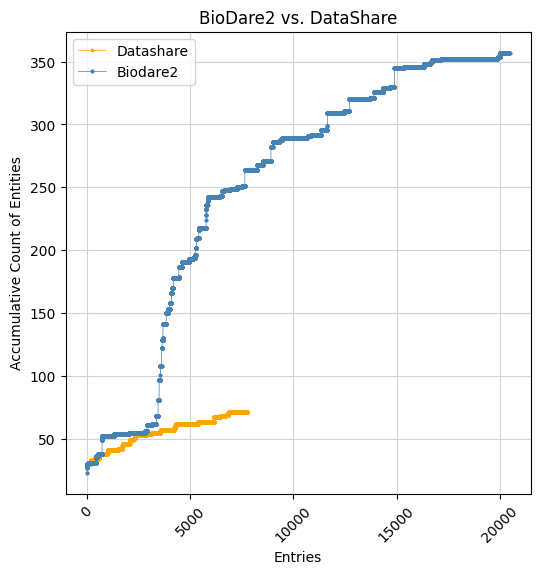

In [144]:
plt.figure(figsize=(6, 6))

plt.plot(
    accumative_counts_datashare.index,
    accumative_counts_datashare['Accumulative_count_entities'],
    marker='s', color='orange', linestyle='-',
    label='Datashare',
    linewidth=0.5,  # ✅ thinner line
    markersize=2
)
plt.plot(
    accumative_counts_biodare2.index,
    accumative_counts_biodare2['Accumulative_count_entities'],
    marker='o', color='steelblue', linestyle='-',
    label='Biodare2',
    linewidth=0.5,  # ✅ thinner line
    markersize=2
)

plt.title('BioDare2 vs. DataShare')
plt.xlabel('Entries')
plt.ylabel('Accumulative Count of Entities')
plt.xticks(rotation=45)
plt.grid(True, color="lightgray")
plt.legend()
plt.show()


In [141]:
accumative_counts_arabidopsis_bd = accumative_counts(df_arabidopsis_bd2 , 'id')
accumative_counts_mus_bd = accumative_counts(df_mus_bd2 , 'id')
accumative_counts_danio = accumative_counts(df_danio_bd2 , 'id')
accumative_counts_drosophila = accumative_counts(df_drosophila_bd2, 'id')
accumative_counts_homo = accumative_counts(df_homo_bd2, 'id')
accumative_counts_synthetic = accumative_counts(df_synthetic_bd2 , 'id')

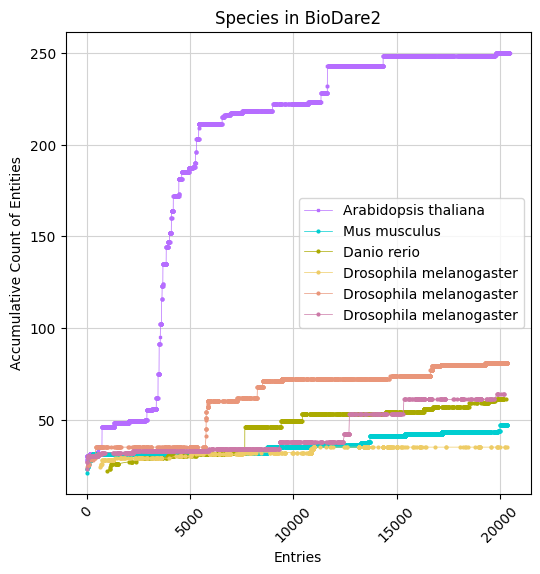

In [143]:
plt.figure(figsize=(6, 6))

plt.plot(
    accumative_counts_arabidopsis_bd.index,
    accumative_counts_arabidopsis_bd['Accumulative_count_entities'],
    marker='s', color='#B66DFF', linestyle='-',
    label='Arabidopsis thaliana',
    linewidth=0.5,  # ✅ thinner line
    markersize=2
)
plt.plot(
    accumative_counts_mus_bd.index,
    accumative_counts_mus_bd['Accumulative_count_entities'],
    marker='o', color='darkturquoise', linestyle='-',
    label='Mus musculus',
    linewidth=0.5,  # ✅ thinner line
    markersize=2
)
plt.plot(
    accumative_counts_danio.index,
    accumative_counts_danio['Accumulative_count_entities'],
    marker='o', color='#AAAA00', linestyle='-',
    label='Danio rerio',
    linewidth=0.5,  # ✅ thinner line
    markersize=2
)
plt.plot(
    accumative_counts_drosophila.index,
    accumative_counts_drosophila['Accumulative_count_entities'],
    marker='o', color='#EECC66', linestyle='-',
    label='Drosophila melanogaster',
    linewidth=0.5,  # ✅ thinner line
    markersize=2
)
plt.plot(
    accumative_counts_homo.index,
    accumative_counts_homo['Accumulative_count_entities'],
    marker='o', color='darksalmon', linestyle='-',
    label='Drosophila melanogaster',
    linewidth=0.5,  # ✅ thinner line
    markersize=2
)
plt.plot(
    accumative_counts_synthetic.index,
    accumative_counts_synthetic['Accumulative_count_entities'],
    marker='o', color='#CC79A7', linestyle='-',
    label='Drosophila melanogaster',
    linewidth=0.5,  # ✅ thinner line
    markersize=2
)

plt.title('Species in BioDare2')
plt.xlabel('Entries')
plt.ylabel('Accumulative Count of Entities')
plt.xticks(rotation=45)
plt.grid(True, color="lightgray")
plt.legend()
plt.show()

In [146]:
accumative_counts_arts_ds = accumative_counts(df_arts_datashare, 'id_in_file')
accumative_counts_medicine_ds = accumative_counts(df_medicine_datashare , 'id_in_file')
accumative_counts_science_ds = accumative_counts(df_science_datashare , 'id_in_file')
accumative_counts_support_ds = accumative_counts(df_support_datashare, 'id_in_file')
accumative_counts_thematic_ds = accumative_counts(df_thematic_datashare, 'id_in_file')

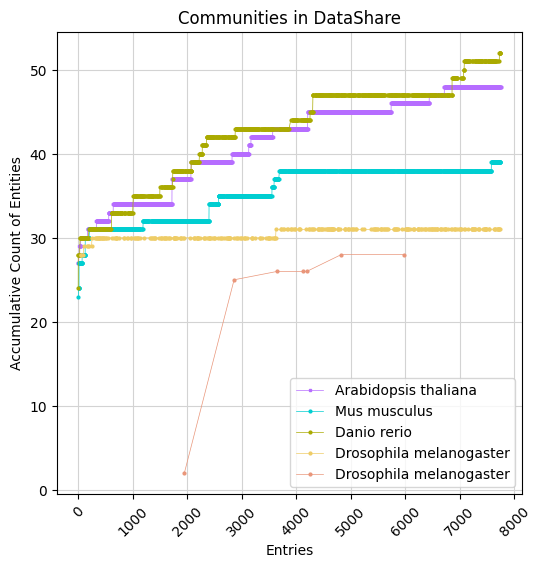

In [149]:
plt.figure(figsize=(6, 6))

plt.plot(
    accumative_counts_arts_ds.index,
    accumative_counts_arts_ds['Accumulative_count_entities'],
    marker='s', color='#B66DFF', linestyle='-',
    label='Arabidopsis thaliana',
    linewidth=0.5,  # ✅ thinner line
    markersize=2
)
plt.plot(
    accumative_counts_medicine_ds.index,
    accumative_counts_medicine_ds['Accumulative_count_entities'],
    marker='o', color='darkturquoise', linestyle='-',
    label='Mus musculus',
    linewidth=0.5,  # ✅ thinner line
    markersize=2
)
plt.plot(
    accumative_counts_science_ds.index,
    accumative_counts_science_ds['Accumulative_count_entities'],
    marker='o', color='#AAAA00', linestyle='-',
    label='Danio rerio',
    linewidth=0.5,  # ✅ thinner line
    markersize=2
)
plt.plot(
    accumative_counts_support_ds.index,
    accumative_counts_support_ds['Accumulative_count_entities'],
    marker='o', color='#EECC66', linestyle='-',
    label='Drosophila melanogaster',
    linewidth=0.5,  # ✅ thinner line
    markersize=2
)
plt.plot(
    accumative_counts_thematic_ds.index,
    accumative_counts_thematic_ds['Accumulative_count_entities'],
    marker='o', color='darksalmon', linestyle='-',
    label='Drosophila melanogaster',
    linewidth=0.5,  # ✅ thinner line
    markersize=2
)


plt.title('Communities in DataShare')
plt.xlabel('Entries')
plt.ylabel('Accumulative Count of Entities')
plt.xticks(rotation=45)
plt.grid(True, color="lightgray")
plt.legend()
plt.show()

In [181]:
print(df_biodare2.columns.tolist())


['Unnamed: 0', 'id', 'versionId', 'generalDesc', 'contributionDesc', 'experimentalDetails', 'characteristic', 'bioDescription', 'bioSummary', 'species', 'dataCategory', 'provenance', 'Name', 'Purpose', 'Description', 'Comments', 'Name_clean', 'Purpose_clean', 'Description_clean', 'Comments_clean', 'Name_words_count', 'Purpose_words_count', 'Description_words_count', 'Comments_words_count', 'Name_clean_word_count', 'Purpose_clean_word_count', 'Description_clean_word_count', 'Comments_clean_word_count', 'Name_clean_lemmatize', 'Name_clean_entities', 'Purpose_clean_lemmatize', 'Purpose_clean_entities', 'Description_clean_lemmatize', 'Description_clean_entities', 'Comments_clean_lemmatize', 'Comments_clean_entities', 'global_counts', 'all_entities', 'entities', 'entities_counter', 'entities_count', 'unique_entities_count', 'ratio_entities_per_word', 'ratio_bin']


### Figure 5 - Word clouds

In [145]:
import ast
import itertools

all_entities_biodare2  = list(itertools.chain.from_iterable(
    df_biodare2['entities'].apply(ast.literal_eval)
))
all_entities_biodare2 = [e.replace('[', '').replace(']', '').replace(" '", '').replace("'", '') for e in all_entities_biodare2]


In [146]:
all_entities_biodare2

['control',
 'global',
 'null growth condition',
 ' experimental condition',
 'biological',
 ' plant metabolism',
 ' growth regulate',
 ' orchestrated',
 ' environment',
 'mutant',
 ' biological',
 ' diurnal light harvest',
 ' transcript',
 ' copy per cell',
 ' cell',
 'mutant',
 ' day',
 ' flowering',
 ' phenotype',
 ' experiment',
 ' partenr',
 ' growth condition',
 ' experimental condition',
 'ld lhy',
 'experiment',
 ' clock model',
 ' exogenous',
 ' sucrose',
 'literature datum',
 ' seedling',
 ' day',
 ' white light shift white light',
 ' degree',
 'sample lose',
 ' genotype',
 ' millar',
 ' manually edit timepoint mutant',
 ' omit ratio',
 ' file',
 ' growth condition',
 ' diurnal',
 ' experimental condition',
 ' sucrose',
 'lhy long marker',
 'seedlle growth',
 'development',
 ' genetic screen',
 ' clock mutant',
 ' developmental mutant',
 ' period',
 ' datum collection',
 ' luciferase',
 ' lhy mutant',
 'datum collection victoria',
 ' hibberd',
 ' millar',
 ' reanalysed',
 ' s

In [140]:
all_entities_datashare  = list(itertools.chain.from_iterable(
    df_datashare['entities'].apply(ast.literal_eval)
))
all_entities_datashare = [e.replace('[', '').replace(']', '').replace(" '", '').replace(" ", '').replace("'", '')  for e in all_entities_datashare]
all_entities_datashare

['block',
 'block',
 'block',
 'wulfruna',
 'wulfruna',
 'grange',
 'authoritywolverhampton',
 'councilimage',
 'towerblock',
 'project',
 'heritagelottery',
 'public',
 'imagearchive',
 'socialarchitectural',
 'socialhousing',
 'coherent',
 'imagearchivesearchabledatabase',
 'image',
 'socialhousing',
 'development',
 'photograph',
 'mileglendinne',
 'public',
 'blockdocument',
 'archivefunction',
 'repository',
 'heritage',
 'catalogueblockpart',
 'development',
 'commission',
 'authority',
 'development',
 'construction',
 'archive',
 'processcommission',
 'construct',
 'socialhousing',
 'accurate',
 'identification',
 'database',
 'archive',
 'block',
 'block',
 'block',
 'block',
 'picardyhousenormandyhouseburgundyhousebrittany',
 'houseimage',
 'block',
 'hilldevelopment',
 'authorityenfieldlondon',
 'councilimage',
 'towerblock',
 'project',
 'heritagelottery',
 'public',
 'imagearchive',
 'socialarchitectural',
 'socialhousing',
 'coherent',
 'imagearchivesearchabledatabase',
 

In [141]:
all_entities_IDR = list(itertools.chain.from_iterable(
    df_IDR['entities'].apply(ast.literal_eval)
))
all_entities_IDR = [e.replace('[', '').replace(']', '').replace(" '", '').replace(" ", '').replace("'", '')  for e in all_entities_IDR]
all_entities_IDR

['intestinal',
 'modelstudy',
 'epithelialbiology',
 'selection',
 'analyticaltool',
 'quantify',
 'heterogeneous',
 'organoid',
 'culture',
 'organoid',
 'chemicalprobe',
 'epigeneticregulator',
 'intestinal',
 'epithelialbiology',
 'epigeneticmodifier',
 'stemcell',
 'intestinalepithelium',
 'undefine',
 'resource',
 'dataset',
 'target',
 'epithelialcell',
 'hdacstypeprmt',
 'complementarymethod',
 'inhibit',
 'typeprmts',
 'epithelialdifferentiationblock',
 'growthadenoma',
 'normal',
 'organoid',
 'epigeneticprobe',
 'intestinal',
 'epithelialbiology',
 'therapeutic',
 'potential',
 'phenotypicprofiling',
 'multiparametricanalysis',
 'cellularphenotype',
 'testingprofiling',
 'effect',
 'bioactivecompound',
 'label',
 'organelleassay',
 'multiplexcytologicalprofiling',
 'paintcell',
 'fluorescentmarker',
 'compromiseability',
 'quantitativeprofile',
 'assay',
 'detect',
 'cellularcomponent',
 'pilotscreen',
 'bioactivecompound',
 'cellular',
 'protein',
 'target',
 'chemicalstruct

### Figure 6 - BioDare entities

In [54]:

df_arabidopsis

,Unnamed: 0,id,versionId,generalDesc,contributionDesc,experimentalDetails,characteristic,bioDescription,bioSummary,species,...,Comments_clean_lemmatize,Comments_clean_entities,global_counts,all_entities,entities,entities_counter,entities_count,unique_entities_count,ratio_entities_per_word,ratio_bin
1,1,2842,2.0.2,timet wp1.1 qrt-pcr elf3 ld | timet focuses on...,"[{'id': none, 'login': none, 'firstname': 'ann...","{'technique': 'rt-pcr', 'equipment': 'perkinel...",false,[],[],arabidopsis thaliana,...,mutant harvest day rest due early flowering ph...,"[mutant, day, flowering, phenotype, experiment...",59,"['[]', '[biological, plant metabolism, growth ...","[""['[biological"", ' plant metabolism', ' growt...","{""['[biological"": 1, ' plant metabolism': 1, '...",19,18,0.322034,"(0.3, 0.4]"
2,2,3492,3.0.3,q-pcr ld (12:12) 17c lhy | experiment to repar...,"[{'id': none, 'login': none, 'firstname': 'aur...","{'technique': 'qrt-pcr', 'equipment': 'robot +...",false,[],[],arabidopsis thaliana,...,sample lose several genotype curate andrew mil...,"[sample lose, genotype, millar, manually edit ...",71,"['[ld lhy]', '[experiment, clock model, exogen...","[""['[ld lhy]'"", "" '[experiment"", ' clock model...","{""['[ld lhy]'"": 1, "" '[experiment"": 1, ' clock...",20,20,0.281690,"(0.2, 0.3]"
3,3,3638,4.0.3,cca1 lhy long #1 cca1 marker | test for period...,"[{'id': none, 'login': none, 'firstname': 'vic...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],arabidopsis thaliana,...,datum collection victoria hibberd can septembe...,"[datum collection victoria, hibberd, millar, r...",80,"['[lhy long marker]', '[seedlle growth]', '[de...","[""['[lhy long marker]'"", "" '[seedlle growth]'""...","{""['[lhy long marker]'"": 1, "" '[seedlle growth...",16,16,0.200000,"(0.1, 0.2]"
4,4,3647,2.0.2,cca1 lhy long #1 cab2 marker | test for period...,"[{'id': none, 'login': none, 'firstname': 'vic...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],arabidopsis thaliana,...,datum collection victoria hibberd can septembe...,"[datum collection victoria, hibberd, millar, r...",80,"['[lhy long marker]', '[seedlle growth]', '[de...","[""['[lhy long marker]'"", "" '[seedlle growth]'""...","{""['[lhy long marker]'"": 1, "" '[seedlle growth...",16,16,0.200000,"(0.1, 0.2]"
5,5,3648,2.0.2,cca1 lhy long #1 ccr2 marker | test for period...,"[{'id': none, 'login': none, 'firstname': 'vic...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],arabidopsis thaliana,...,datum collection victoria hibberd can septembe...,"[datum collection victoria, hibberd, millar, r...",91,"['[lhy long marker]', '[seedlle growth]', '[de...","[""['[lhy long marker]'"", "" '[seedlle growth]'""...","{""['[lhy long marker]'"": 1, "" '[seedlle growth...",18,18,0.197802,"(0.1, 0.2]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20464,20464,13650039169340,2.0.2,270313h3: 12l-12dx4 llx3 | 'white' (red+blue) ...,"[{'id': none, 'login': none, 'firstname': 'jam...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],arabidopsis thaliana,...,null growth condition const w experimental con...,"[null growth condition, experimental condition]",24,"['[]', '[white redblue light control, experime...","[""['[white redblue light control"", "" experimen...","{""['[white redblue light control"": 1, "" experi...",6,6,0.250000,"(0.2, 0.3]"
20465,20465,13661271159675,2.0.2,030413h3: 12b-12dx4 bb3 | test how the cryptoc...,"[{'id': none, 'login': none, 'firstname': 'jam...","{'technique': 'luciferase luminescence', 'equi...",false,[],[],arabidopsis thaliana,...,null growth condition const w experimental con...,"[null growth condition, experimental condition]",26,"['[]', '[cryptochrome, circadian, clock, doubl...","[""['[cryptochrome"", ' circadian', ' clock', "" ...","{""['[cryptochrome"": 1, ' circadian': 1, ' cloc...",7,7,0.269231,"(0.2, 0.3]"
20466,20466,13790739219191,2.0.3,"niwa et al. (2007); gi, fkf1, cdf1, co, f

In [55]:
import pandas as pd
from collections import Counter
import ast

def flatten_and_count_entities(df, entity_col='entities'):
    all_entities = []
    
    for entry in df[entity_col]:
        # Handle actual lists
        if isinstance(entry, list):
            all_entities.extend(entry)
        # Handle string representations of lists
        elif isinstance(entry, str):
            try:
                parsed = ast.literal_eval(entry)
                if isinstance(parsed, list):
                    all_entities.extend(parsed)
            except (ValueError, SyntaxError):
                all_entities.append(entry)

     # Clean: remove [ ] and strip whitespace
    all_entities = [
        str(e).replace('[', '').replace(']', '').replace("'", '').strip()
        for e in all_entities
    ]
    
    cleaned_entity = [
        re.sub(r"[^\w\s\-]", '', str(e)).strip()
        for e in all_entities
    ]
    
    # Remove empty strings if needed
    all_entities = [e.strip() for e in cleaned_entity if str(e).strip() != '']
    
    # Count and sort
    counter = Counter(all_entities)
    counts_df = pd.DataFrame(
        counter.most_common(),
        columns=['entity', 'count']
    )
    return counts_df



In [56]:
# Apply to a single dataframe
entity_counts = flatten_and_count_entities(df_biodare2, entity_col='entities')
print(entity_counts.head(20))


                          entity  count
0   automatically publish system  10769
1                      circadian   3164
2                            day   2746
3                          clock   1935
4                         period   1693
5                     experiment   1653
6                      zebrafish    960
7                          plant    897
8               circadian rhythm    863
9                      condition    768
10                    expression    746
11                       testing    733
12                   temperature    712
13                        mutant    648
14                   oscillation    595
15                         mouse    595
16                        effect    583
17                     treatment    573
18                         check    540
19                   arabidopsis    529


In [57]:
# Apply to a single dataframe
entity_counts = flatten_and_count_entities(df_biodare2, entity_col='entities')
print(entity_counts.head(20))

                          entity  count
0   automatically publish system  10769
1                      circadian   3164
2                            day   2746
3                          clock   1935
4                         period   1693
5                     experiment   1653
6                      zebrafish    960
7                          plant    897
8               circadian rhythm    863
9                      condition    768
10                    expression    746
11                       testing    733
12                   temperature    712
13                        mutant    648
14                   oscillation    595
15                         mouse    595
16                        effect    583
17                     treatment    573
18                         check    540
19                   arabidopsis    529


In [58]:
top_10_to_remove = set(entity_counts.head(10)['entity'].tolist())
print("Removing these 10 entities:") 
print(top_10_to_remove)

Removing these 10 entities:
{'period', 'day', 'zebrafish', 'experiment', 'plant', 'circadian rhythm', 'condition', 'automatically publish system', 'clock', 'circadian'}


In [59]:
entity_counts_arabidopsis = flatten_and_count_entities(df_arabidopsis, entity_col='entities')
entity_counts_mus = flatten_and_count_entities(df_mus, entity_col='entities')
entity_counts_drosophila = flatten_and_count_entities(df_drosophila, entity_col='entities')
entity_counts_synthetic = flatten_and_count_entities(df_synthetic, entity_col='entities')

In [84]:
filtered_counts_df_arabidopsis = entity_counts_arabidopsis[~entity_counts_arabidopsis['entity'].isin(top_10_to_remove) ].reset_index(drop=True)
arabidopsis_top15 = filtered_counts_df_arabidopsis.head(15)
arabidopsis_top15 

,entity,count
0,arabidopsis,512
1,seedling,456
2,mutant,369
3,leaf,358
4,testing,321
5,expression,313
6,google sheet,284
7,hour,233
8,temperature,219
9,treatment,205


In [92]:
filtered_counts_df_mus = entity_counts_mus[~entity_counts_mus['entity'].isin(top_10_to_remove) ].reset_index(drop=True)
mus_top15 = filtered_counts_df_mus.head(15)
mus_top15

,entity,count
0,mouse,375
1,treatment,273
2,analysis tool,242
3,oscillation,157
4,baseline,148
5,ultradian,140
6,stability,138
7,expression,135
8,effect,135
9,test effect,129


In [93]:
filtered_counts_df_drosophila = entity_counts_drosophila[~entity_counts_drosophila['entity'].isin(top_10_to_remove) ].reset_index(drop=True)
drosophila_top15 = filtered_counts_df_drosophila.head(15)
drosophila_top15

,entity,count
0,male,264
1,female,123
2,thesis,79
3,testing,56
4,ceiling occupancy,49
5,datum,26
6,calexa system,23
7,diurnal,22
8,seasonality,21
9,calex,20


In [94]:
filtered_counts_df_synthetic = entity_counts_synthetic[~entity_counts_synthetic['entity'].isin(top_10_to_remove) ].reset_index(drop=True)
synthetic_top15 = filtered_counts_df_synthetic.head(15)
synthetic_top15

,entity,count
0,temperature,132
1,compare,83
2,strain,78
3,measure,59
4,check,55
5,blue light,54
6,mutant,46
7,amplitude,46
8,test,43
9,detrende method,43


##### All together

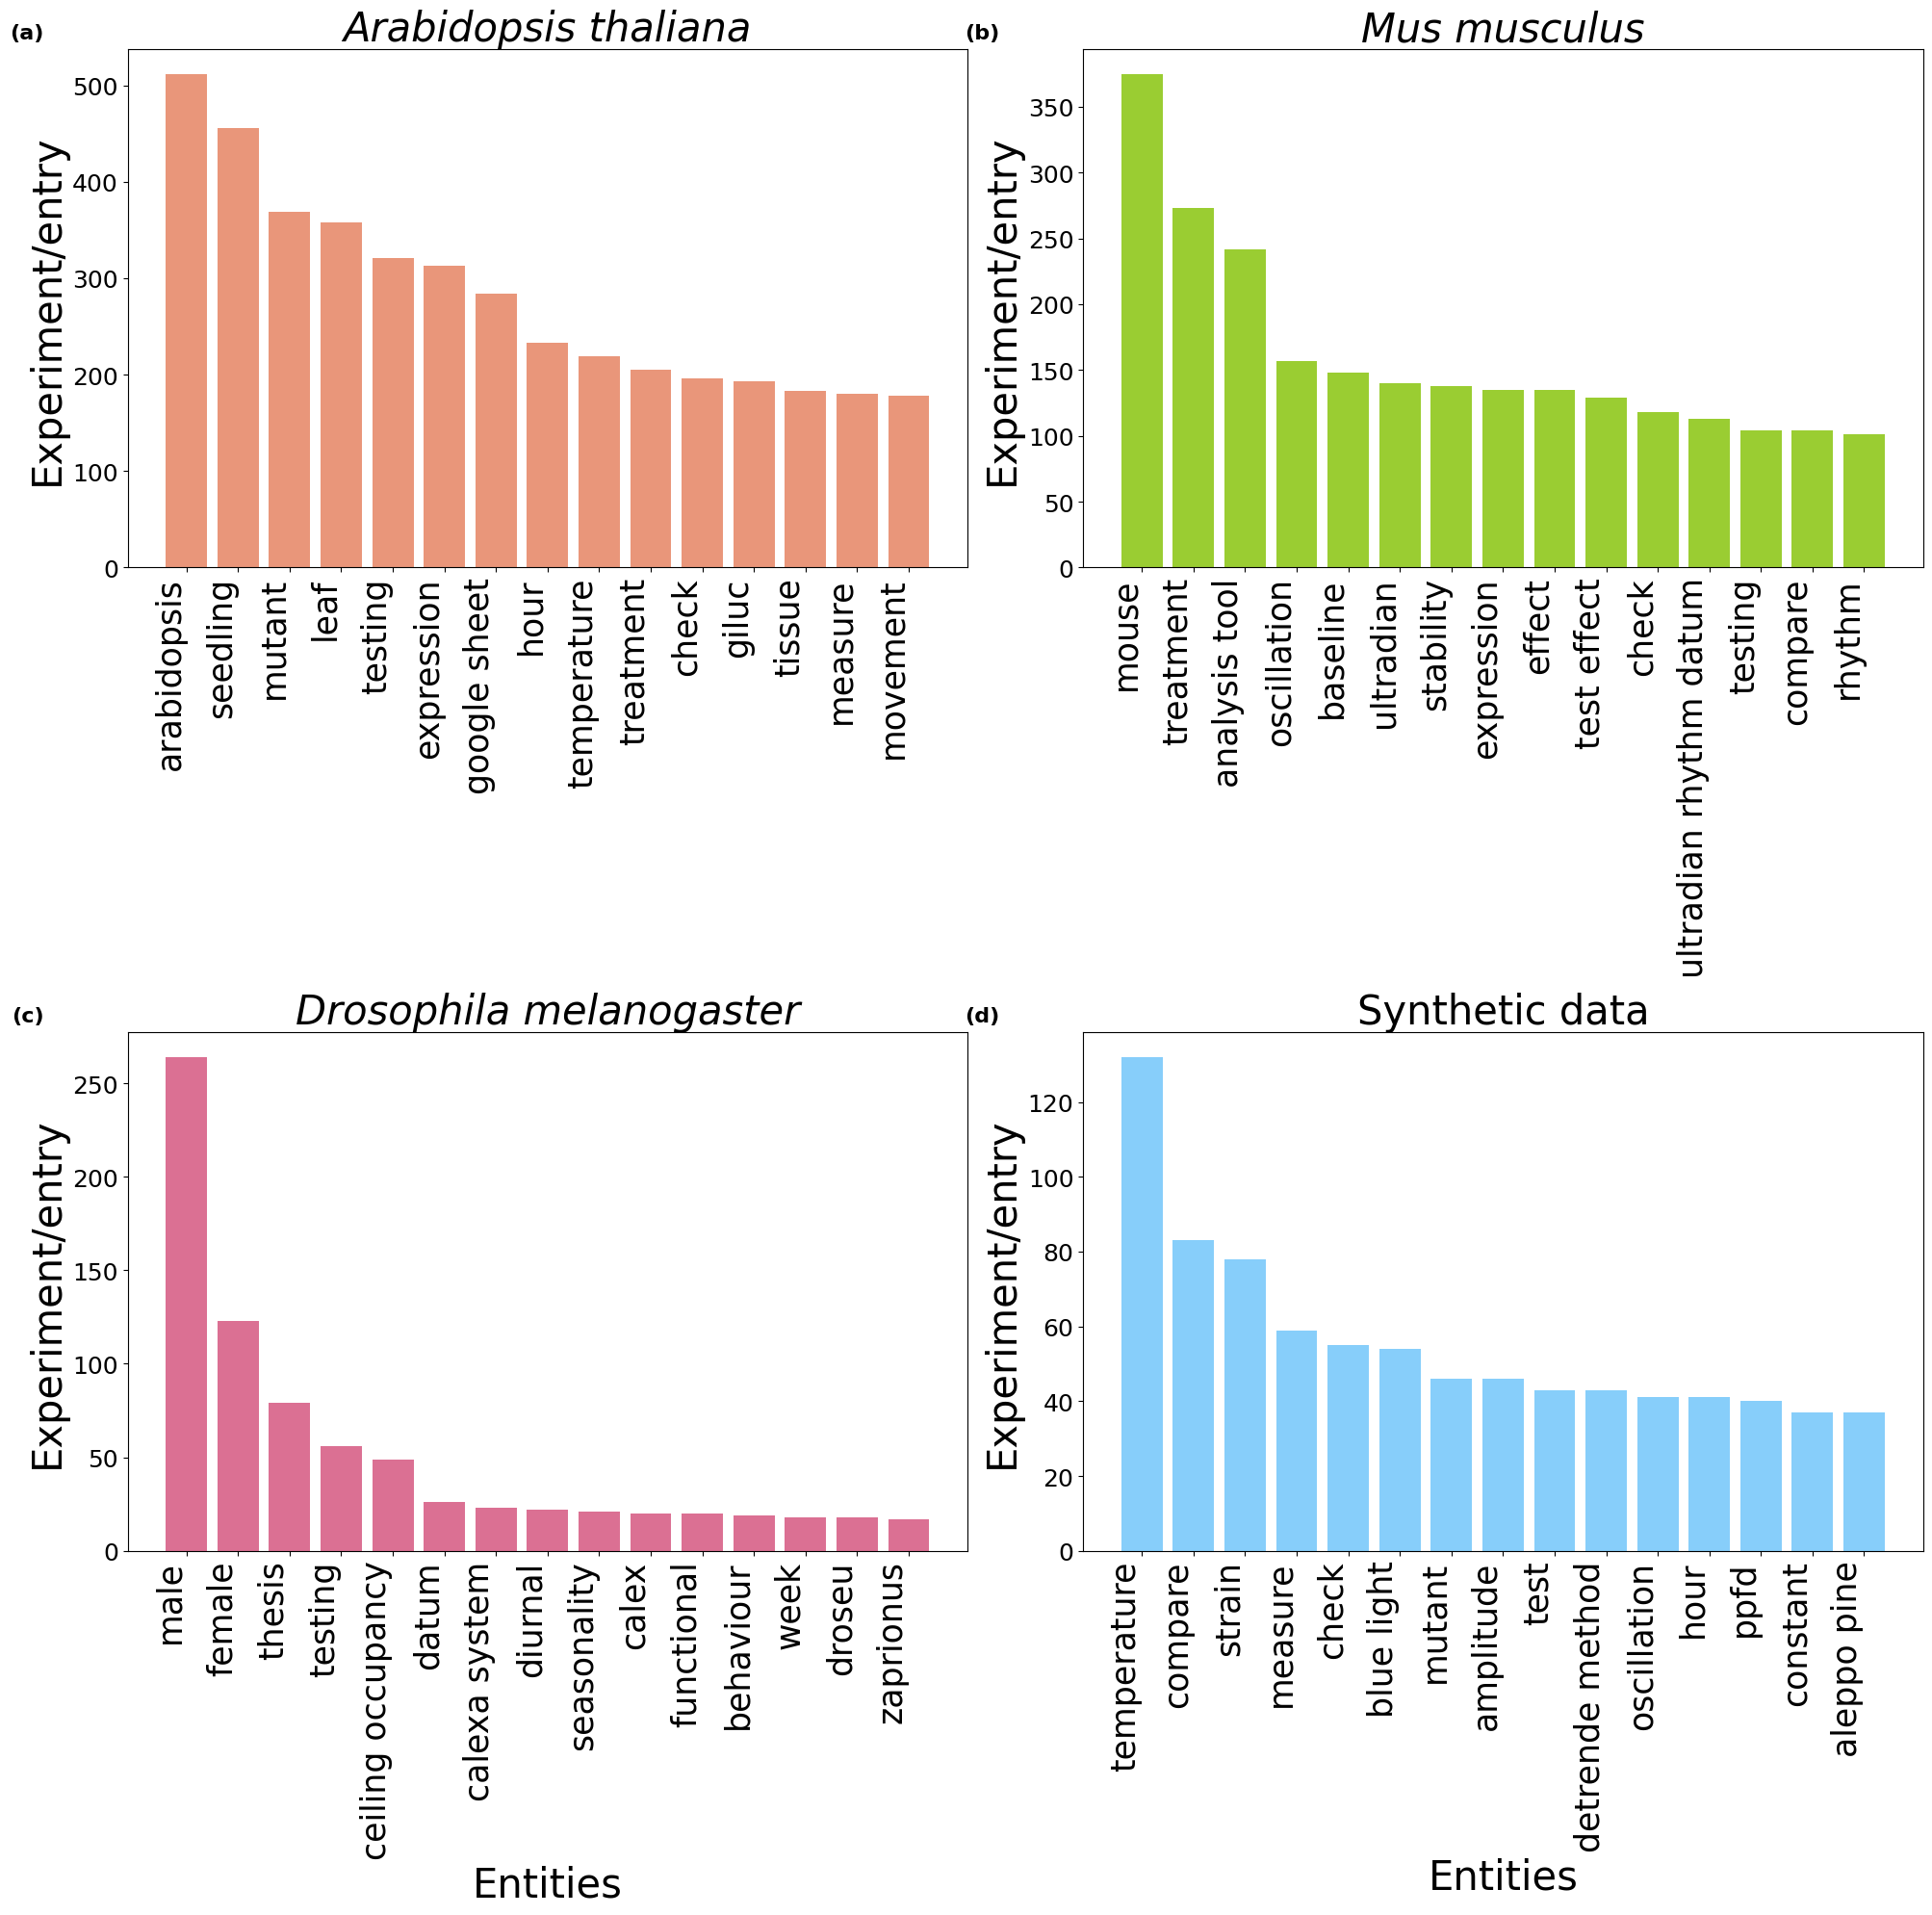

In [156]:
fig, axes = plt.subplots(2, 2, figsize=(20, 20))


## Arabidopsis thaliana ##
axes[0,0].bar(arabidopsis_top15['entity'], arabidopsis_top15['count'], color="darksalmon")
axes[0,0].set_title("Arabidopsis thaliana", fontsize=30, style="italic")
#axes[0,0].set_xlabel("Entities", fontsize=10)
axes[0,0].set_ylabel("Experiment/entry", fontsize=30)
axes[0,0].tick_params(axis='both', labelsize=18)
axes[0,0].set_xticks(range(len(arabidopsis_top15['entity'])))
axes[0,0].set_xticklabels(arabidopsis_top15['entity'], fontsize=25, rotation=90, ha="right")


## Mus musculus ##
axes[0,1].bar(mus_top15['entity'], mus_top15['count'], color="yellowgreen")
axes[0,1].set_title("Mus musculus", fontsize=30, style="italic")
#axes[0,1].set_xlabel("Entities", fontsize=10)
axes[0,1].set_ylabel("Experiment/entry", fontsize=30)
axes[0,1].tick_params(axis='both', labelsize=18)
axes[0,1].set_xticks(range(len(mus_top15['entity'])))
axes[0,1].set_xticklabels(mus_top15['entity'], fontsize=25, rotation=90, ha="right")


## Drosphila melanogaster ##
axes[1,0].bar(drosophila_top15['entity'], drosophila_top15['count'], color="palevioletred")
axes[1,0].set_title("Drosophila melanogaster", fontsize=30, style="italic")
axes[1,0].set_xlabel("Entities", fontsize=30)
axes[1,0].set_ylabel("Experiment/entry", fontsize=30)
axes[1,0].tick_params(axis='both', labelsize=18)
axes[1,0].set_xticks(range(len(drosophila_top15['entity'])))
axes[1,0].set_xticklabels(drosophila_top15['entity'], fontsize=25, rotation=90, ha="right")


## Synthetic data ##
axes[1,1].bar(synthetic_top15['entity'], synthetic_top15['count'], color="lightskyblue")
axes[1,1].set_title("Synthetic data", fontsize=30)
axes[1,1].set_xlabel("Entities", fontsize=30)
axes[1,1].set_ylabel("Experiment/entry", fontsize=30)
axes[1,1].tick_params(axis='both', labelsize=18)
axes[1,1].set_xticks(range(len(synthetic_top15['entity'])))
axes[1,1].set_xticklabels(synthetic_top15['entity'], fontsize=25, rotation=90, ha="right")



for ax, label in zip(axes.flat, ['(a)', '(b)', '(c)', '(d)']):
    ax.text(
        -0.1, 1.05, label,
        transform=ax.transAxes,   # now matches the loop variable
        fontsize=16,
        fontweight='bold',
        va='top', ha='right'
    )
plt.subplots_adjust(hspace=0.3, wspace=0.3)
plt.tight_layout()


plt.savefig("Figure6_entities_BioDare2_20260818.pdf", dpi=300, bbox_inches="tight")   # vector — best for publications
plt.savefig("Figure6_entities_BioDare2_20260818.tiff", dpi=300, bbox_inches="tight")  # often required by journals
plt.savefig("Figure6_entities_BioDare2_20260818.svg", dpi=300, bbox_inches="tight")   # editable vector


### Scatter plot information density vs. lenght

In [9]:
df_biodare2.columns

Index(['Unnamed: 0', 'id', 'versionId', 'generalDesc', 'contributionDesc',
       'experimentalDetails', 'characteristic', 'bioDescription', 'bioSummary',
       'species', 'dataCategory', 'provenance', 'Name', 'Purpose',
       'Description', 'Comments', 'Name_clean', 'Purpose_clean',
       'Description_clean', 'Comments_clean', 'Name_words_count',
       'Purpose_words_count', 'Description_words_count',
       'Comments_words_count', 'Name_clean_word_count',
       'Purpose_clean_word_count', 'Description_clean_word_count',
       'Comments_clean_word_count', 'Name_clean_lemmatize',
       'Name_clean_entities', 'Purpose_clean_lemmatize',
       'Purpose_clean_entities', 'Description_clean_lemmatize',
       'Description_clean_entities', 'Comments_clean_lemmatize',
       'Comments_clean_entities', 'global_counts', 'all_entities', 'entities',
       'entities_counter', 'entities_count', 'unique_entities_count',
       'ratio_entities_per_word', 'ratio_bin'],
      dtype='str')

In [13]:
x = df_biodare2["global_counts"]
x

0         15
1         59
2         71
3         80
4         80
        ... 
20466    149
20467     49
20468     31
20469     38
20470    118
Name: global_counts, Length: 20471, dtype: int64

In [14]:
y = df_biodare2["ratio_entities_per_word"]
y

0        0.266667
1        0.322034
2        0.281690
3        0.200000
4        0.200000
           ...   
20466    0.288591
20467    0.265306
20468    0.290323
20469    0.368421
20470    0.279661
Name: ratio_entities_per_word, Length: 20471, dtype: float64

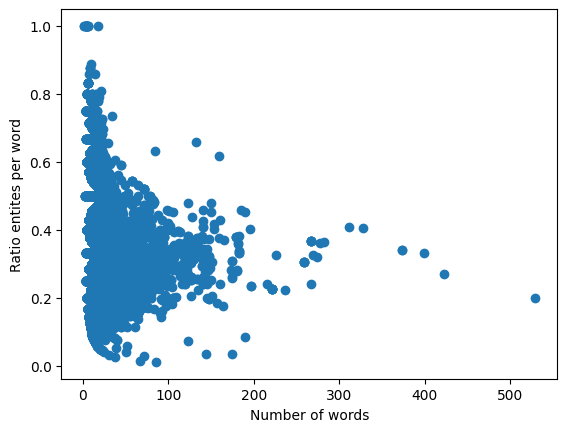

In [15]:
plt.scatter(x,y)
plt.xlabel("Number of words")
plt.ylabel("Ratio entites per word")
plt.show()

In [18]:
import numpy as np
from scipy.optimize import curve_fit

x = df_biodare2["global_counts"].to_numpy()
y = df_biodare2["ratio_entities_per_word"].to_numpy()

def linear(x, a, b):
    return a*x + b

def quadratic(x, a, b, c):
    return a*x**2 + b*x + c

def exponential(x, a, b, c):
    return a*np.exp(b*x) + c

def powerlaw(x, a, b, c):
    return a*(x**b) + c

models = {
    "linear": (linear, None),
    "quadratic": (quadratic, None),
    "exponential": (exponential, None),
    "powerlaw": (powerlaw, None),
}

fits = {}
for name, (f, p0) in models.items():
    try:
        popt, pcov = curve_fit(f, x, y, p0=p0, maxfev=20000)
        yhat = f(x, *popt)
        rss = np.sum((y - yhat)**2)
        fits[name] = (popt, rss)
    except Exception as e:
        fits[name] = ("failed", str(e))

fits



{'linear': ('failed', 'array must not contain infs or NaNs'),
 'quadratic': ('failed', 'array must not contain infs or NaNs'),
 'exponential': ('failed', 'array must not contain infs or NaNs'),
 'powerlaw': ('failed', 'array must not contain infs or NaNs')}

In [19]:
print("NaNs in x:", np.isnan(x).sum())
print("NaNs in y:", np.isnan(y).sum())
print("+inf/-inf in x:", np.isinf(x).sum())
print("+inf/-inf in y:", np.isinf(y).sum())


NaNs in x: 0
NaNs in y: 2
+inf/-inf in x: 0
+inf/-inf in y: 0


In [20]:
df2 = df_biodare2[["global_counts", "ratio_entities_per_word"]].replace([np.inf, -np.inf], np.nan).dropna()
x2 = df2["global_counts"].to_numpy(float)
y2 = df2["ratio_entities_per_word"].to_numpy(float)


In [21]:
import numpy as np
from scipy.optimize import curve_fit

x = df2["global_counts"].to_numpy()
y = df2["ratio_entities_per_word"].to_numpy()

def linear(x, a, b):
    return a*x + b

def quadratic(x, a, b, c):
    return a*x**2 + b*x + c

def exponential(x, a, b, c):
    return a*np.exp(b*x) + c

def powerlaw(x, a, b, c):
    return a*(x**b) + c

models = {
    "linear": (linear, None),
    "quadratic": (quadratic, None),
    "exponential": (exponential, None),
    "powerlaw": (powerlaw, None),
}

fits = {}
for name, (f, p0) in models.items():
    try:
        popt, pcov = curve_fit(f, x, y, p0=p0, maxfev=20000)
        yhat = f(x, *popt)
        rss = np.sum((y - yhat)**2)
        fits[name] = (popt, rss)
    except Exception as e:
        fits[name] = ("failed", str(e))

fits


/opt/conda/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:1024: RuntimeWarning: overflow encountered in square
  cost = np.sum(infodict['fvec'] ** 2)
/opt/conda/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:1062: RuntimeWarning: invalid value encountered in multiply
  pcov = pcov * s_sq
/tmp/ipykernel_2378/1282767426.py:31: RuntimeWarning: overflow encountered in square
  rss = np.sum((y - yhat)**2)


{'linear': (array([-0.00089206,  0.3763771 ]), 337.98774286324397),
 'quadratic': (array([ 5.42707653e-06, -1.83386722e-03,  3.89392525e-01]),
  334.2917474398508),
 'exponential': (array([-2.72244641e-016,  1.00000000e+000,  1.43478855e+143]),
  inf),
 'powerlaw': (array([-4.59444755e+02,  1.07370143e-04,  4.59935472e+02]),
  325.49741657461954)}

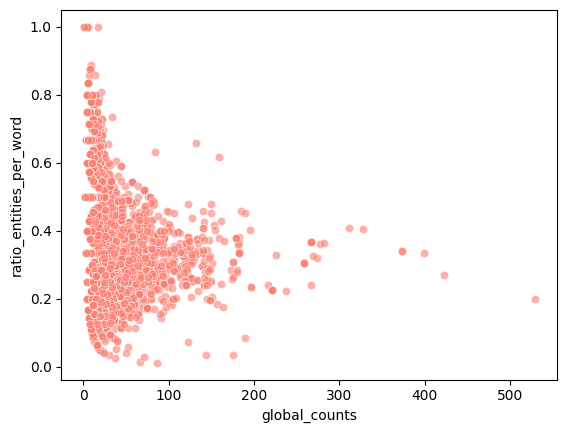

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df_biodare2, x=df_biodare2["global_counts"], y= df2["ratio_entities_per_word"], alpha=0.6,  color="salmon")
#sns.regplot(data=df_biodare2, x=df_biodare2["global_counts"], y= df2["ratio_entities_per_word"], scatter=False, lowess=True, color="red")
plt.show()


In [30]:
df_IDR.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Comment[IDR_Study_Accession]',
       'Study_Title', 'Study_Type', 'Study_Type_Term_Source_REF',
       'Study_Type_Term_Accession', 'Study_Description', 'Study_Key_Words',
       'Study_Organism',
       ...
       'Experiment_Description_clean_entities', 'all_entities', 'entities',
       'entities_counter', 'entities_count', 'unique_entities_count',
       'all_entities_clean_entities_white_spaces', 'global_counts',
       'ratio_entities_per_word', 'ratio_bin'],
      dtype='str', length=241)

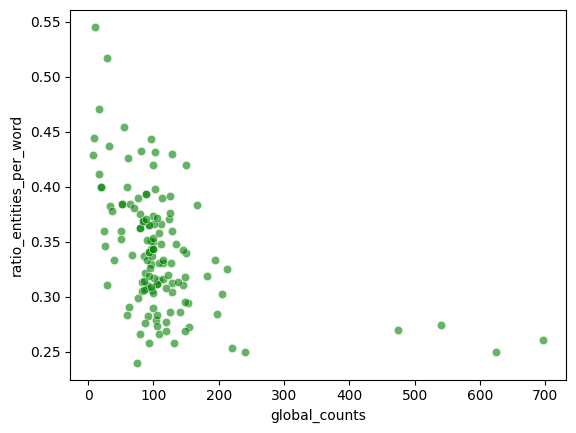

In [33]:
sns.scatterplot(data=df_IDR, x=df_IDR["global_counts"], y= df_IDR["ratio_entities_per_word"], alpha=0.6,  color="green")
#sns.regplot(data=df_biodare2, x=df_biodare2["global_counts"], y= df2["ratio_entities_per_word"], scatter=False, lowess=True, color="red")
plt.show()

In [38]:
df_datashare.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'dc.contributor', 'dc.contributor.other',
       'dc.coverage.spatial', 'dc.coverage.temporal', 'dc.creator',
       'dc.date.accessioned', 'dc.date.available', 'dc.identifier.citation',
       'dc.identifier.uri', 'dc.description.abstract', 'dc.language.iso',
       'dc.publisher', 'dc.relation.isreferencedby', 'dc.rights', 'dc.subject',
       'dc.subject.classification', 'dc.title', 'dc.type', 'file_name',
       'collection', 'id_in_file', 'dc.relation.isversionof',
       'dc.description.tableofcontents', 'dc.source', 'dc.title.alternative',
       'dc.relation.isreplacedby', 'dc.date.updated', 'dc.date.embargo',
       'dc.relation.replaces', 'dc.source.uri', 'dc.date.issued',
       'dcterms.subject', 'dcterms.isReferencedBy', 'dc.contributor.advisor',
       'dc.relation.hasversion', 'dc.contributor.author', 'dc.description',
       'dc.description.sponsorship', 'dc.relation.ispartofseries',
       'ds.withdrawn.showtombstone', 'dc.relation.

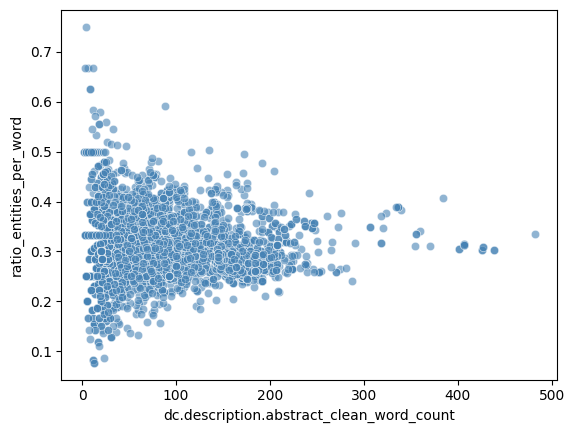

In [42]:
sns.scatterplot(data=df_datashare, x=df_datashare["dc.description.abstract_clean_word_count"], y= df_datashare["ratio_entities_per_word"], alpha=0.6,  color="steelblue")
#sns.regplot(data=df_biodare2, x=df_biodare2["global_counts"], y= df2["ratio_entities_per_word"], scatter=False, lowess=True, color="red")
plt.show()